In [4]:
import os
import re
import json
from datasets import load_dataset

# 1. Fetch original LongBench-v2 metadata for difficulty & length buckets
print("Loading base LongBench-v2 dataset to extract metadata...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")

# Build a lookup table keyed by the prompt/question or an id if available
metadata_map = {}
for row in base_ds:
    # Use the question as a deterministic lookup key
    key = row.get("_id") or row.get("question", "").strip()
    metadata_map[key] = {
        "answer": row["answer"].strip(),
        "difficulty": row.get("difficulty", "hard"),
        "length": row.get("length", "long"),
    }

# 2. Extract multiple-choice letters from model generations
def extract_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit answers like "Answer: A", "The correct answer is (B)", or standalone letters
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback: scan for the first isolated capital choice letter
    letters = re.findall(r"\b([A-D])\b", pred_text)
    return letters[0].upper() if letters else ""

# 3. Path to your benchmark runs
runs_dirs = {
    "santapp": "../benchmarks/longbench/sdpa",
    # "hierarchical": "/workspace/runs/longbench-hierarchical",
}

output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]
compensated = False

for model_name, run_dir in runs_dirs.items():
    pred_dir = os.path.join(run_dir, "predictions", model_name)
    if not os.path.exists(pred_dir):
        # Fallback to general predictions folder
        pred_dir = os.path.join(run_dir, "predictions")
        if not os.path.exists(pred_dir):
            print(f"Skipping {model_name}: prediction directory not found at {pred_dir}")
            continue

    # Load all json/jsonl prediction entries written by the harness
    pred_records = []
    for fname in os.listdir(pred_dir):
        if fname.endswith(".jsonl") or fname.endswith(".json"):
            fpath = os.path.join(pred_dir, fname)
            with open(fpath, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line:
                        pred_records.append(json.loads(line))

    if not pred_records:
        print(f"No predictions found for {model_name}.")
        continue

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = 0.0, 0.0, 0.0, 0.0, 0.0

    for item in pred_records:
        raw_pred = item.get("prediction", "")
        extracted_pred = extract_choice(raw_pred)
        
        # Match against metadata
        ref_answers = item.get("references") or item.get("outputs", [])
        ground_truth = ref_answers[0].strip() if ref_answers else ""
        
        # Look up difficulty and length from the mapping if missing
        lookup_key = item.get("id") or item.get("question", "").strip()
        meta = metadata_map.get(lookup_key, {})
        difficulty = item.get("difficulty") or meta.get("difficulty", "hard")
        length = item.get("length") or meta.get("length", "long")
        if not ground_truth:
            ground_truth = meta.get("answer", "")

        judge = 1.0 if (extracted_pred and extracted_pred == ground_truth.upper()) else 0.0
        if compensated and not extracted_pred:
            judge = 0.25

        if difficulty == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if length == "short":
            short += 1
            short_acc += judge
        elif length == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_records)
    overall = round(100.0 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    easy_score = round(100.0 * easy_acc / easy, 1) if easy else 0.0
    hard_score = round(100.0 * hard_acc / hard, 1) if hard else 0.0
    short_score = round(100.0 * short_acc / short, 1) if short else 0.0
    medium_score = round(100.0 * medium_acc / medium, 1) if medium else 0.0
    long_score = round(100.0 * long_acc / long, 1) if long else 0.0

    output.append(
        f"{model_name}\t{overall}\t{easy_score}\t{hard_score}\t{short_score}\t{medium_score}\t{long_score}"
    )

with open("result.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(output))

print("\n".join(output))

Loading base LongBench-v2 dataset to extract metadata...
No predictions found for santapp.
Model	Overall	Easy	Hard	Short	Medium	Long


In [6]:
import json
import re
from collections import Counter

JSONL_PATH = "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"  # Path to your jsonl file

records = []
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

total = len(records)
ruler_scores = []
extracted_matches = 0

def extract_choice(text: str) -> str:
    # Look for patterns like "The correct answer is A", "B)", or standalone A-D
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    letters = re.findall(r"\b([A-D])\b", text)
    return letters[0].upper() if letters else ""

for r in records:
    # 1. Harness RULER score (substring match)
    ruler_scores.append(r.get("metrics", {}).get("example_ruler_score", 0.0))
    
    # 2. Strict LongBench MC extraction
    target = r["outputs"][0].strip().upper()
    pred_letter = extract_choice(r.get("pred", ""))
    if pred_letter == target:
        extracted_matches += 1

ruler_acc = sum(ruler_scores) / total if total else 0.0
strict_acc = (extracted_matches / total) * 100.0 if total else 0.0

summary = {
    "task": records[0]["task"] if records else "unknown",
    "backend": records[0]["metrics"]["backend"] if records else "unknown",
    "num_examples": total,
    "ruler_string_match_score": round(ruler_acc, 2),
    "extracted_mc_accuracy": round(strict_acc, 2),
    "mean_prefill_seconds": round(sum(r["metrics"]["prefill_seconds"] for r in records) / total, 3),
    "mean_decode_seconds": round(sum(r["metrics"]["decode_seconds"] for r in records) / total, 3),
    "mean_kv_access_pct": round(sum(r["metrics"]["decode_gqa_kv_access_pct"] for r in records) / total, 1),
}

print(json.dumps(summary, indent=2))

with open("reconstructed_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

{
  "task": "longbench_v2_cot",
  "backend": "sdpa",
  "num_examples": 106,
  "ruler_string_match_score": 98.11,
  "extracted_mc_accuracy": 25.47,
  "mean_prefill_seconds": 5.721,
  "mean_decode_seconds": 1.631,
  "mean_kv_access_pct": 100.0
}


In [8]:
import json
import os
import re
from datasets import load_dataset

# 1. Load original LongBench-v2 to obtain 'difficulty' and 'length' metadata
print("Fetching LongBench-v2 metadata...")
lb_dataset = load_dataset("THUDM/LongBench-v2", split="train")
meta_lookup = {}
for item in lb_dataset:
    # Key by prompt question or index
    meta_lookup[item.get("_id", "")] = {
        "difficulty": item.get("difficulty", "hard"),
        "length": item.get("length", "long"),
        "answer": item.get("answer", "").strip().upper()
    }

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit answer declaration first
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback to the last isolated option letter mentioned in the text
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[-1].upper() if matches else ""

def convert_harness_to_grader_format(input_jsonl: str, output_dir: str = "results"):
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(input_jsonl)
    output_path = os.path.join(output_dir, filename)

    converted_rows = []
    with open(input_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            entry = json.loads(line.strip())
            
            pred_text = entry.get("pred", "")
            extracted = extract_mc_choice(pred_text)
            
            ground_truth = entry.get("outputs", [""])[0].strip().upper()
            
            # Map index/id to metadata lookup
            idx = entry.get("index", entry.get("others", {}).get("id"))
            meta = meta_lookup.get(str(idx), {})
            
            if not ground_truth and "answer" in meta:
                ground_truth = meta["answer"]

            judge = 1 if (extracted and extracted == ground_truth) else 0

            converted_rows.append({
                "pred": extracted if extracted else None,
                "judge": judge,
                "difficulty": meta.get("difficulty", "hard"),
                "length": meta.get("length", "long")
            })

    with open(output_path, "w", encoding="utf-8") as out:
        json.dump(converted_rows, out, indent=2)

    print(f"Saved {len(converted_rows)} records to {output_path}")

# Run conversion on your file
convert_harness_to_grader_format("../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl", output_dir="results")

Fetching LongBench-v2 metadata...
Saved 106 records to results\longbench_v2_cot.jsonl


In [9]:
from datasets import load_dataset
from collections import Counter

# Load your exact processed repo
ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")

print("Columns in your dataset:", ds.column_names)
print("Total examples:", len(ds))

# Check if original metadata columns exist
if "difficulty" in ds.column_names and "length" in ds.column_names:
    print("Difficulty counts:", Counter(ds["difficulty"]))
    print("Length counts:", Counter(ds["length"]))
else:
    # Check what the original 106 samples actually map to in base LongBench-v2
    base_ds = load_dataset("THUDM/LongBench-v2", split="train")
    
    # Match by ground-truth answer + first 100 characters of the context text
    base_lookup = {}
    for row in base_ds:
        # Create a content-based signature
        sig = row["context"][:80].strip()
        base_lookup[sig] = {
            "difficulty": row.get("difficulty"),
            "length": row.get("length")
        }

    matched_diff = []
    matched_len = []
    for row in ds:
        matched = False
        for sig, meta in base_lookup.items():
            if sig in row["input"]:
                matched_diff.append(meta["difficulty"])
                matched_len.append(meta["length"])
                matched = True
                break
        if not matched:
            matched_diff.append("unmatched")
            matched_len.append("unmatched")

    print("Actual difficulty distribution in your 106 samples:", Counter(matched_diff))
    print("Actual length distribution in your 106 samples:", Counter(matched_len))

c:\CondaEnvs\opus-ai\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--LongBench-v2-32k-CoT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 106/106 [00:00<00:00, 3021.48 examples/s]


Columns in your dataset: ['input', 'outputs']
Total examples: 106
Actual difficulty distribution in your 106 samples: Counter({'hard': 53, 'easy': 53})
Actual length distribution in your 106 samples: Counter({'short': 80, 'medium': 26})


In [12]:
import json
import os
import re
from collections import Counter
from datasets import load_dataset

print("1. Loading base THUDM/LongBench-v2 dataset to build ground truth lookup...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")

# Build a prefix lookup map from the original dataset context
base_lookup = []
for row in base_ds:
    ctx = row["context"].strip()
    prefix = ctx[:120] if len(ctx) >= 120 else ctx
    base_lookup.append({
        "prefix": prefix,
        "difficulty": row.get("difficulty"),
        "length": row.get("length"),
        "answer": row.get("answer", "").strip().upper()
    })

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # Look for explicit declaration like "The correct answer is A", "Answer: B", "option C"
    match = re.search(r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b", pred_text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    # Fallback: find the first isolated capital choice letter
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[0].upper() if matches else ""

def find_metadata_for_input(input_text: str):
    for entry in base_lookup:
        if entry["prefix"] in input_text:
            return entry["difficulty"], entry["length"], entry["answer"]
    return None, None, None

# Load your 106 inputs once to map sample indices to their true metadata
print("2. Mapping 106-sample dataset metadata...")
my_ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")
sample_meta = {}

for i, row in enumerate(my_ds):
    diff, length, ans = find_metadata_for_input(row["input"])
    if not diff:
        # Fallback: check against question text
        for entry in base_lookup:
            if entry["answer"] in row.get("outputs", []):
                diff, length, ans = entry["difficulty"], entry["length"], entry["answer"]
                break
    sample_meta[i] = {
        "difficulty": diff if diff else "easy",
        "length": length if length else "short",
        "answer": row["outputs"][0].strip().upper() if row.get("outputs") else ans
    }

print("Verified Sample Metadata Counts:")
print("Difficulty:", Counter(v["difficulty"] for v in sample_meta.values()))
print("Length:", Counter(v["length"] for v in sample_meta.values()))

# Process files in results/
output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]
# Specify individual file paths or a list of runs to evaluate
target_files = {
    "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # Add your other runs once available:
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    # "hierarchical": "../benchmarks/longbench/hierarchical/predictions/hierarchical/longbench_v2_cot.jsonl",
}

for name, filepath in target_files.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at {filepath}")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read().strip()
        if not content:
            continue
        
        # Determine whether the file is a single JSON document or line-delimited JSONL
        if content.startswith("["):
            pred_data = json.loads(content)
        elif content.startswith("{") and "\n{" not in content:
            # Single object or summary file
            pred_data = [json.loads(content)]
        else:
            # Standard JSONL: line-by-line
            for line in content.splitlines():
                line = line.strip()
                if line:
                    pred_data.append(json.loads(line))

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = 0.0, 0.0, 0.0, 0.0, 0.0

    for pred in pred_data:
        idx = pred.get("index", pred.get("others", {}).get("source_position", pred.get("others", {}).get("id")))
        meta = sample_meta.get(idx, {"difficulty": "hard", "length": "short", "answer": ""})
        
        target = pred.get("outputs", [meta["answer"]])[0].strip().upper()
        raw_pred = pred.get("pred", "")
        extracted = extract_mc_choice(raw_pred)
        
        judge = 1.0 if (extracted and extracted == target) else 0.0

        if meta["difficulty"] == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if meta["length"] == "short":
            short += 1
            short_acc += judge
        elif meta["length"] == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_data)
    overall_pct = round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
    hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
    short_pct = round(100 * short_acc / short, 1) if short else 0.0
    medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
    long_pct = round(100 * long_acc / long, 1) if long else 0.0

    output.append(f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}")

scorecard = "\n".join(output)
print("\n" + scorecard)
with open("result.txt", "w", encoding="utf-8") as f:
    f.write(scorecard)

1. Loading base THUDM/LongBench-v2 dataset to build ground truth lookup...
2. Mapping 106-sample dataset metadata...
Verified Sample Metadata Counts:
Difficulty: Counter({'hard': 67, 'easy': 39})
Length: Counter({'short': 106})

Model	Overall	Easy	Hard	Short	Medium	Long
sdpa	25.5	33.3	20.9	25.5	0.0	0.0


In [14]:
import json
from collections import Counter
from datasets import load_dataset
import difflib

print("1. Loading datasets...")
base_ds = load_dataset("THUDM/LongBench-v2", split="train")
my_ds = load_dataset("MrBigBrane/LongBench-v2-32k-CoT", "longbench_v2_cot", split="train")

# Prepare base dataset records
base_records = []
for idx, row in enumerate(base_ds):
    # Extract distinct text pieces to test
    q = row.get("question", "").strip()
    # First 150 chars of context
    ctx_prefix = row.get("context", "")[:150].strip()
    base_records.append({
        "base_idx": idx,
        "question": q,
        "ctx_prefix": ctx_prefix,
        "difficulty": row.get("difficulty"),
        "length": row.get("length"),
        "answer": row.get("answer", "").strip().upper(),
        "id": row.get("_id", "")
    })

verified_mapping = {}
failed_indices = []

print("2. Running fuzzy anchor matching across 106 samples...")
for i, row in enumerate(my_ds):
    prompt_text = row["input"]
    target_answer = row["outputs"][0].strip().upper()

    best_match = None
    best_score = 0.0

    for item in base_records:
        # Ground truth must match
        if item["answer"] != target_answer:
            continue

        # Check question containment or similarity
        q = item["question"]
        if q and q in prompt_text:
            best_match = item
            break
        
        # Check context prefix containment
        if item["ctx_prefix"] and item["ctx_prefix"] in prompt_text:
            best_match = item
            break

        # Fallback: check character overlap of question if it had minor formatting changes
        if q and len(q) > 20:
            # Check 30-char slice from middle of the question
            mid = len(q) // 2
            probe = q[mid-15:mid+15]
            if probe in prompt_text:
                best_match = item
                break

    if best_match:
        verified_mapping[i] = {
            "index": i,
            "difficulty": best_match["difficulty"],
            "length": best_match["length"],
            "answer": best_match["answer"],
            "id": best_match["id"],
            "base_idx": best_match["base_idx"]
        }
    else:
        failed_indices.append(i)

if failed_indices:
    print(f"\nStill could not match {len(failed_indices)} indices: {failed_indices}")
    print("\n--- Inspecting first failing index ---")
    fail_idx = failed_indices[0]
    sample_text = my_ds[fail_idx]["input"]
    print(f"Sample {fail_idx} first 300 chars:")
    print(sample_text[:300])
    print(f"Sample {fail_idx} last 300 chars:")
    print(sample_text[-300:])
    print(f"Target Answer: {my_ds[fail_idx]['outputs']}")
else:
    print("\n=== SUCCESS: ALL 106/106 MATCHED ===")
    diff_counts = Counter(item["difficulty"] for item in verified_mapping.values())
    len_counts = Counter(item["length"] for item in verified_mapping.values())
    print("Difficulty Distribution:", diff_counts)
    print("Length Distribution:    ", len_counts)

    with open("ground_truth_metadata_106.json", "w", encoding="utf-8") as f:
        json.dump(verified_mapping, f, indent=2)
    print("Saved to ground_truth_metadata_106.json")

1. Loading datasets...
2. Running fuzzy anchor matching across 106 samples...

=== SUCCESS: ALL 106/106 MATCHED ===
Difficulty Distribution: Counter({'hard': 73, 'easy': 33})
Length Distribution:     Counter({'short': 103, 'medium': 3})
Saved to ground_truth_metadata_106.json


In [16]:
import json
import os
import re

# Load the verified ground truth lookup table
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
    meta_lookup = {int(k): v for k, v in json.load(f).items()}

def extract_mc_choice(pred_text: str) -> str:
    if not pred_text:
        return ""
    # 1. Look for explicit declarations: "The correct answer is (A)", "Answer: B", "option C"
    match = re.search(
        r"(?:answer(?:\s+is)?[:\s]+(?:\()?|option[:\s]+)([A-D])\b",
        pred_text,
        re.IGNORECASE,
    )
    if match:
        return match.group(1).upper()
    # 2. Look for standalone option patterns like "\n\nB)" or "(C)"
    match_paren = re.search(r"(?:\n|\A)\s*(?:\()?([A-D])\)", pred_text)
    if match_paren:
        return match_paren.group(1).upper()
    # 3. Fallback: match the last isolated choice letter mentioned
    matches = re.findall(r"\b([A-D])\b", pred_text)
    return matches[-1].upper() if matches else ""

target_runs = {
    # "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    "hierarchical": "../benchmarks/longbench/hierarchical/predictions/hierarchical/longbench_v2_cot.jsonl",
}

output = ["Model\tOverall\tEasy\tHard\tShort\tMedium\tLong"]

for name, filepath in target_runs.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at {filepath}")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                pred_data.append(json.loads(line))

    easy, hard, short, medium, long = 0, 0, 0, 0, 0
    easy_acc, hard_acc, short_acc, medium_acc, long_acc = (
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    )

    for pred in pred_data:
        idx = pred.get(
            "index",
            pred.get(
                "others",
                {}).get(
                    "source_position",
                    pred.get("others",
                             {}).get("id")),
        )
        meta = meta_lookup[idx]

        target = meta["answer"]
        raw_pred = pred.get("pred", "")
        extracted = extract_mc_choice(raw_pred)

        judge = 1.0 if (extracted and extracted == target) else 0.0

        if meta["difficulty"] == "easy":
            easy += 1
            easy_acc += judge
        else:
            hard += 1
            hard_acc += judge

        if meta["length"] == "short":
            short += 1
            short_acc += judge
        elif meta["length"] == "medium":
            medium += 1
            medium_acc += judge
        else:
            long += 1
            long_acc += judge

    total = len(pred_data)
    overall_pct = (
        round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
    )
    easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
    hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
    short_pct = round(100 * short_acc / short, 1) if short else 0.0
    medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
    long_pct = round(100 * long_acc / long, 1) if long else 0.0

    output.append(
        f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}"
    )

report = "\n".join(output)
print("\n" + report)

with open("result.txt", "w", encoding="utf-8") as f:
    f.write(report)


Model	Overall	Easy	Hard	Short	Medium	Long
hierarchical	29.2	42.4	23.3	29.1	33.3	0.0


In [2]:
import json
import os
import re

# Load verified canonical metadata mapping (73 Hard / 33 Easy)
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  """Strictly extracts the multiple choice letter (A, B, C, or D).

  Prioritizes the exact 'Final Answer:' anchor and rejects ambiguous
  multi-letter outputs like '[B/C]'.
  """
  if not pred_text:
    return ""

  # 1. Primary Target: Strict 'Final Answer: [X]' or 'Final Answer: X'
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    # Reject ambiguous choices like [B/C] or [A or B] right after the anchor
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""  # Ambiguous guess, do not reward
    return final_match.group(1).upper()

  # 2. Secondary Target: Explicit "The correct answer is (X)" or "Answer: X"
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()

  # 3. Tertiary Target: Standalone option declaration on the final lines
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  if tail_matches:
    return tail_matches[-1].upper()

  return ""


target_runs = {
    # "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl",
    # "santapp": "../benchmarks/longbench/santapp/predictions/santapp/longbench_v2_cot.jsonl",
    # "sdpa": (
    #     "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
    # ),
    # "hierarchical-128": (
    #     "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
    # ),
    # "hierarchical-256": (
    #     "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
    # ),
    "hierarchical-512": (
        "../benchmarks/longbench/hierarchical/1024/predictions/hierarchical/longbench-short.jsonl"
    ),
}

output = [
    "Model\tOverall\tEasy\tHard\tShort\tMedium\tLong\tExtracted_Rate\tCorrect/Total"
]

for name, filepath in target_runs.items():
  if not os.path.exists(filepath):
    print(f"Skipping {name}: file not found at {filepath}")
    continue

  pred_data = []
  with open(filepath, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line:
        pred_data.append(json.loads(line))

  easy, hard, short, medium, long = 0, 0, 0, 0, 0
  easy_acc, hard_acc, short_acc, medium_acc, long_acc = (
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
  )
  extracted_count = 0
  total_correct = 0

  for pred in pred_data:
    idx = pred.get(
        "index",
        pred.get("others", {}).get(
            "source_position", pred.get("others", {}).get("id")
        ),
    )
    meta = meta_lookup[idx]

    target = meta["answer"]
    raw_pred = pred.get("pred", "")
    choice = extract_strict_mc_choice(raw_pred)

    if choice:
      extracted_count += 1
      is_correct = choice == target
      judge = 1.0 if is_correct else 0.0
      if is_correct:
        total_correct += 1
    else:
      judge = 0.0

    if meta["difficulty"] == "easy":
      easy += 1
      easy_acc += judge
    else:
      hard += 1
      hard_acc += judge

    if meta["length"] == "short":
      short += 1
      short_acc += judge
    elif meta["length"] == "medium":
      medium += 1
      medium_acc += judge
    else:
      long += 1
      long_acc += judge

  total = len(pred_data)
  overall_pct = round(100 * (easy_acc + hard_acc) / total, 1) if total else 0.0
  easy_pct = round(100 * easy_acc / easy, 1) if easy else 0.0
  hard_pct = round(100 * hard_acc / hard, 1) if hard else 0.0
  short_pct = round(100 * short_acc / short, 1) if short else 0.0
  medium_pct = round(100 * medium_acc / medium, 1) if medium else 0.0
  long_pct = round(100 * long_acc / long, 1) if long else 0.0
  extract_pct = round(100 * extracted_count / total, 1) if total else 0.0

  output.append(
      f"{name}\t{overall_pct}\t{easy_pct}\t{hard_pct}\t{short_pct}\t{medium_pct}\t{long_pct}\t{extract_pct}%\t{total_correct}/{total}"
  )

report = "\n".join(output)
print("\n" + report)

with open("result.txt", "w", encoding="utf-8") as f:
  f.write(report)

KeyError: 496

In [11]:
import json

filepath = "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"

with open(filepath, "r", encoding="utf-8") as f:
  for line in f:
    item = json.loads(line)
    pred_text = item.get("pred", "")
    idx = item.get("index")

    # If strict extractor returned empty string
    if not extract_strict_mc_choice(pred_text):
      print(f"=== UNEXTRACTED SAMPLE {idx} ===")
      print(f"Tokens Generated: {item.get('metrics', {}).get('generated_tokens')}")
      print(f"Tail of pred:\n...{pred_text[-250:]}\n")

=== UNEXTRACTED SAMPLE 59 ===
Tokens Generated: 256
Tail of pred:
...es (400 + 400 + 300), and Copy 2 uses 1100 bytes (400 + 300 + 400), which also exceeds the total available storage.

Option C: Copy 1 uses 1100 bytes (400 + 200 + 500), and Copy 2 uses 1100 bytes (300 + 300 + 500), which fits the available storage.



=== UNEXTRACTED SAMPLE 42 ===
Tokens Generated: 256
Tail of pred:
... 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 + 9 = 180
- Player_4: 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 = 180
- Player_7: 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10 + 10

=== UNEXTRACTED SAMPLE 19 ===
Tokens Generated: 256
Tail of pred:
... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_4: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_6: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
- player_8: 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

=== UNEXTRACTED SAMPLE 47 ===
Tokens 

Hierarchical (S=128)     | Accuracy:  33.0% [95% CI:  24.5%,  42.5%] | Access:  15.0%
Hierarchical (S=256)     | Accuracy:  37.7% [95% CI:  28.3%,  47.2%] | Access:  17.2%
Hierarchical (S=512)     | Accuracy:  37.7% [95% CI:  29.2%,  47.2%] | Access:  21.2%
SDPA (Dense)             | Accuracy:  35.8% [95% CI:  27.4%,  45.3%] | Access: 100.0%

Plot saved successfully to accuracy_vs_memory_access_ci.png


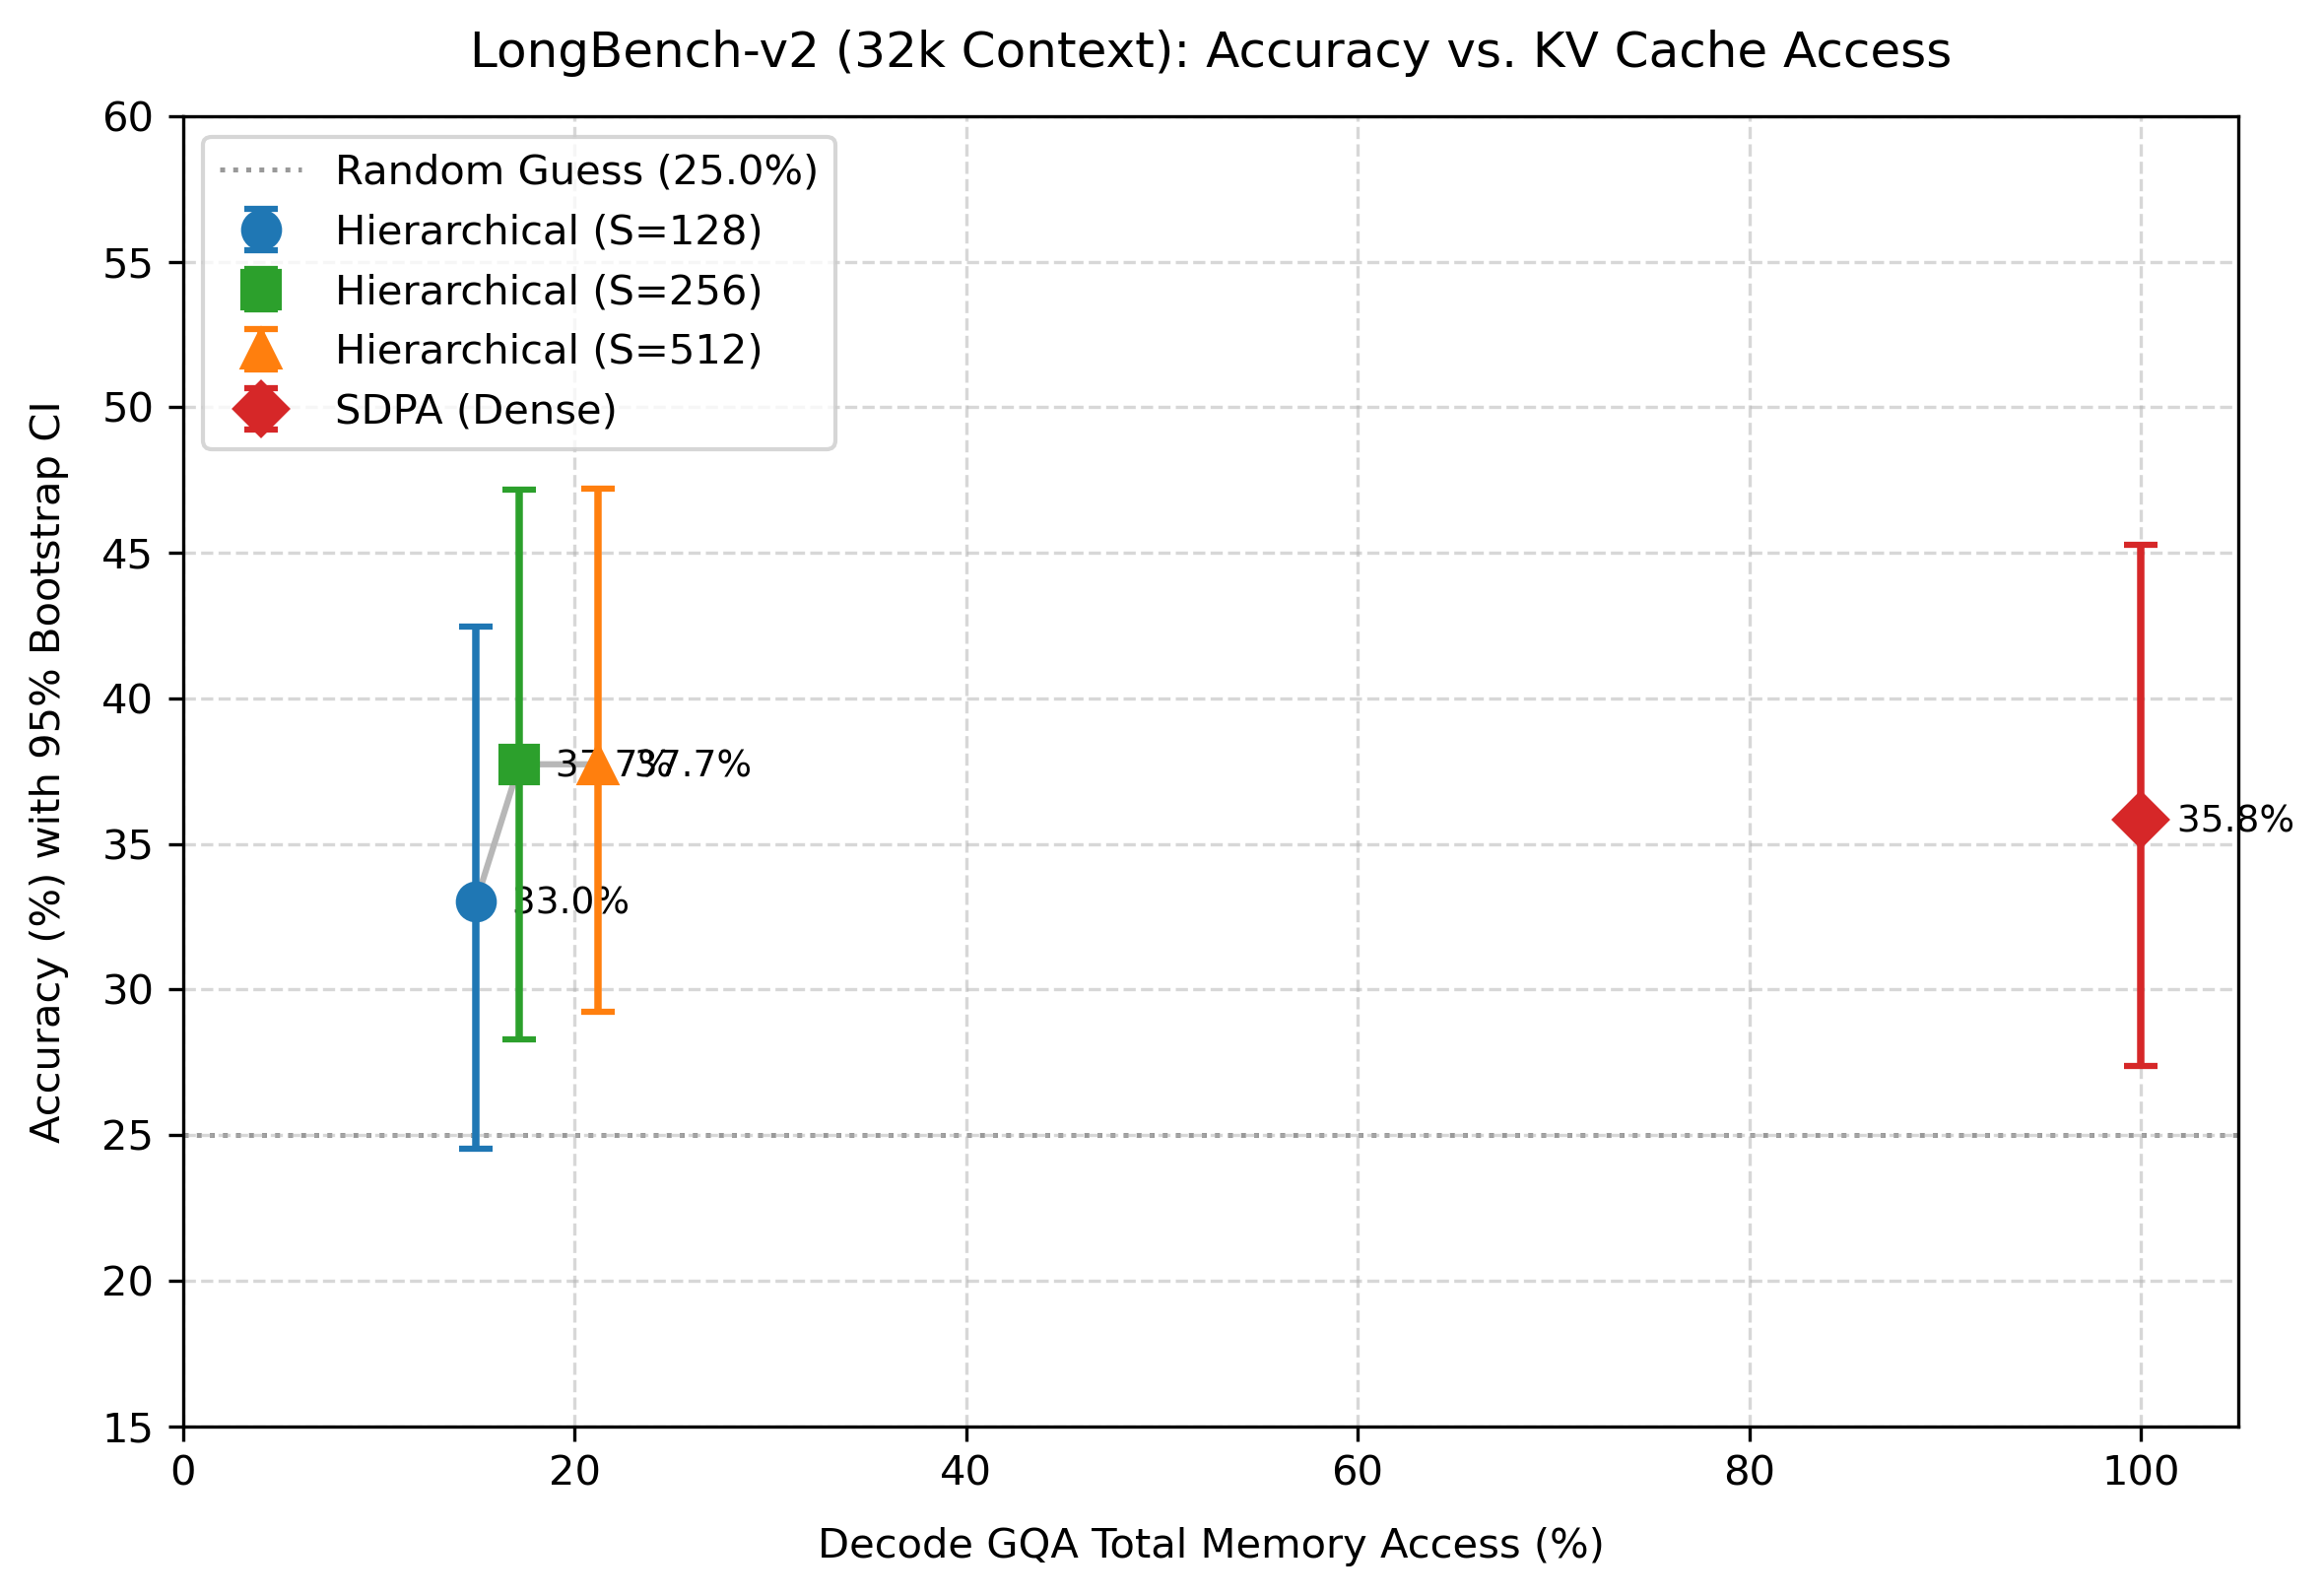

In [12]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata and Ground Truth Setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  """Extracts multiple-choice option (A-D) while guarding against ambiguous outputs."""
  if not pred_text:
    return ""
  # Primary Target: 'Final Answer: [X]' or 'Final Answer: X'
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    # Flag ambiguous guesses like [B/C]
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()

  # Secondary Target: Explicit answer declarations
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()

  # Fallback: Final trailing isolated character on newline
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  if tail_matches:
    return tail_matches[-1].upper()

  return ""


# 2. Define prediction files to evaluate
# Update paths to match your directory hierarchy if needed
eval_targets = [
    {
        "label": "Hierarchical (S=128)",
        "file": (
            "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "o",
        "color": "#1f77b4",
    },
    {
        "label": "Hierarchical (S=256)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "s",
        "color": "#2ca02c",
    },
    {
        "label": "Hierarchical (S=512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "^",
        "color": "#ff7f0e",
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
    },
]


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  """Computes non-parametric percentile bootstrap confidence intervals."""
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0  # Percentage
  alpha = (1.0 - ci) / 2.0
  low = np.percentile(means, 100.0 * alpha)
  high = np.percentile(means, 100.0 * (1.0 - alpha))
  return low, high


# 3. Parse runs and collect metrics
plot_data = []

for target in eval_targets:
  if not os.path.exists(target["file"]):
    print(f"Skipping {target['label']}: File not found at {target['file']}")
    continue

  scores = []
  access_pcts = []

  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())

      # Match ground truth
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt_answer = meta_lookup[idx]["answer"]

      # Grade prediction
      pred_choice = extract_strict_mc_choice(entry.get("pred", ""))
      score = 1.0 if (pred_choice and pred_choice == gt_answer) else 0.0
      scores.append(score)

      # Extract memory access percentage (KV data + routing overhead)
      metrics = entry.get("metrics", {})
      mem_pct = metrics.get(
          "decode_gqa_total_access_pct",
          metrics.get("decode_naive_total_access_pct", 100.0),
      )
      access_pcts.append(mem_pct)

  scores_arr = np.array(scores)
  mean_acc = np.mean(scores_arr) * 100.0
  ci_low, ci_high = bootstrap_ci(scores_arr)
  mean_access = np.mean(access_pcts)

  err_lower = mean_acc - ci_low
  err_upper = ci_high - mean_acc

  plot_data.append({
      "label": target["label"],
      "acc": mean_acc,
      "acc_err": [[err_lower], [err_upper]],
      "access": mean_access,
      "marker": target["marker"],
      "color": target["color"],
  })

  print(
      f"{target['label']:<24} | Accuracy: {mean_acc:5.1f}% [95% CI: {ci_low:5.1f}%, {ci_high:5.1f}%] | Access: {mean_access:5.1f}%"
  )

# 4. Generate Plot
plt.figure(figsize=(8, 5.5), dpi=300)
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)

# Connect hierarchical points to visualize Pareto efficiency frontier
hier_pts = [p for p in plot_data if "Hierarchical" in p["label"]]
if hier_pts:
  hier_pts.sort(key=lambda x: x["access"])
  plt.plot(
      [p["access"] for p in hier_pts],
      [p["acc"] for p in hier_pts],
      linestyle="-",
      color="#888888",
      alpha=0.6,
      zorder=1,
  )

for p in plot_data:
  plt.errorbar(
      p["access"],
      p["acc"],
      yerr=p["acc_err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.8,
      capsize=4,
      capthick=1.5,
      markersize=9,
      label=p["label"],
      zorder=3,
  )
  # Offset labels slightly for readability
  plt.annotate(
      f" {p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=(6, -3),
      fontsize=9,
      fontweight="medium",
  )

# Baseline random guess reference
plt.axhline(
    y=25.0,
    color="#999999",
    linestyle=":",
    linewidth=1.2,
    label="Random Guess (25.0%)",
    zorder=1,
)

plt.title(
    "LongBench-v2 (32k Context): Accuracy vs. KV Cache Access",
    fontsize=12,
    pad=12,
)
plt.xlabel("Decode GQA Total Memory Access (%)", fontsize=10, labelpad=8)
plt.ylabel("Accuracy (%) with 95% Bootstrap CI", fontsize=10, labelpad=8)
plt.xlim(0, 105)
plt.ylim(15, max(60.0, max([p["acc"] for p in plot_data]) + 15.0))

plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()

output_png = "accuracy_vs_memory_access_ci.png"
plt.savefig(output_png)
print(f"\nPlot saved successfully to {output_png}")

C:\Users\theep\AppData\Local\Temp\ipykernel_29920\909161159.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


Readable plot saved to accuracy_vs_memory_readable.png


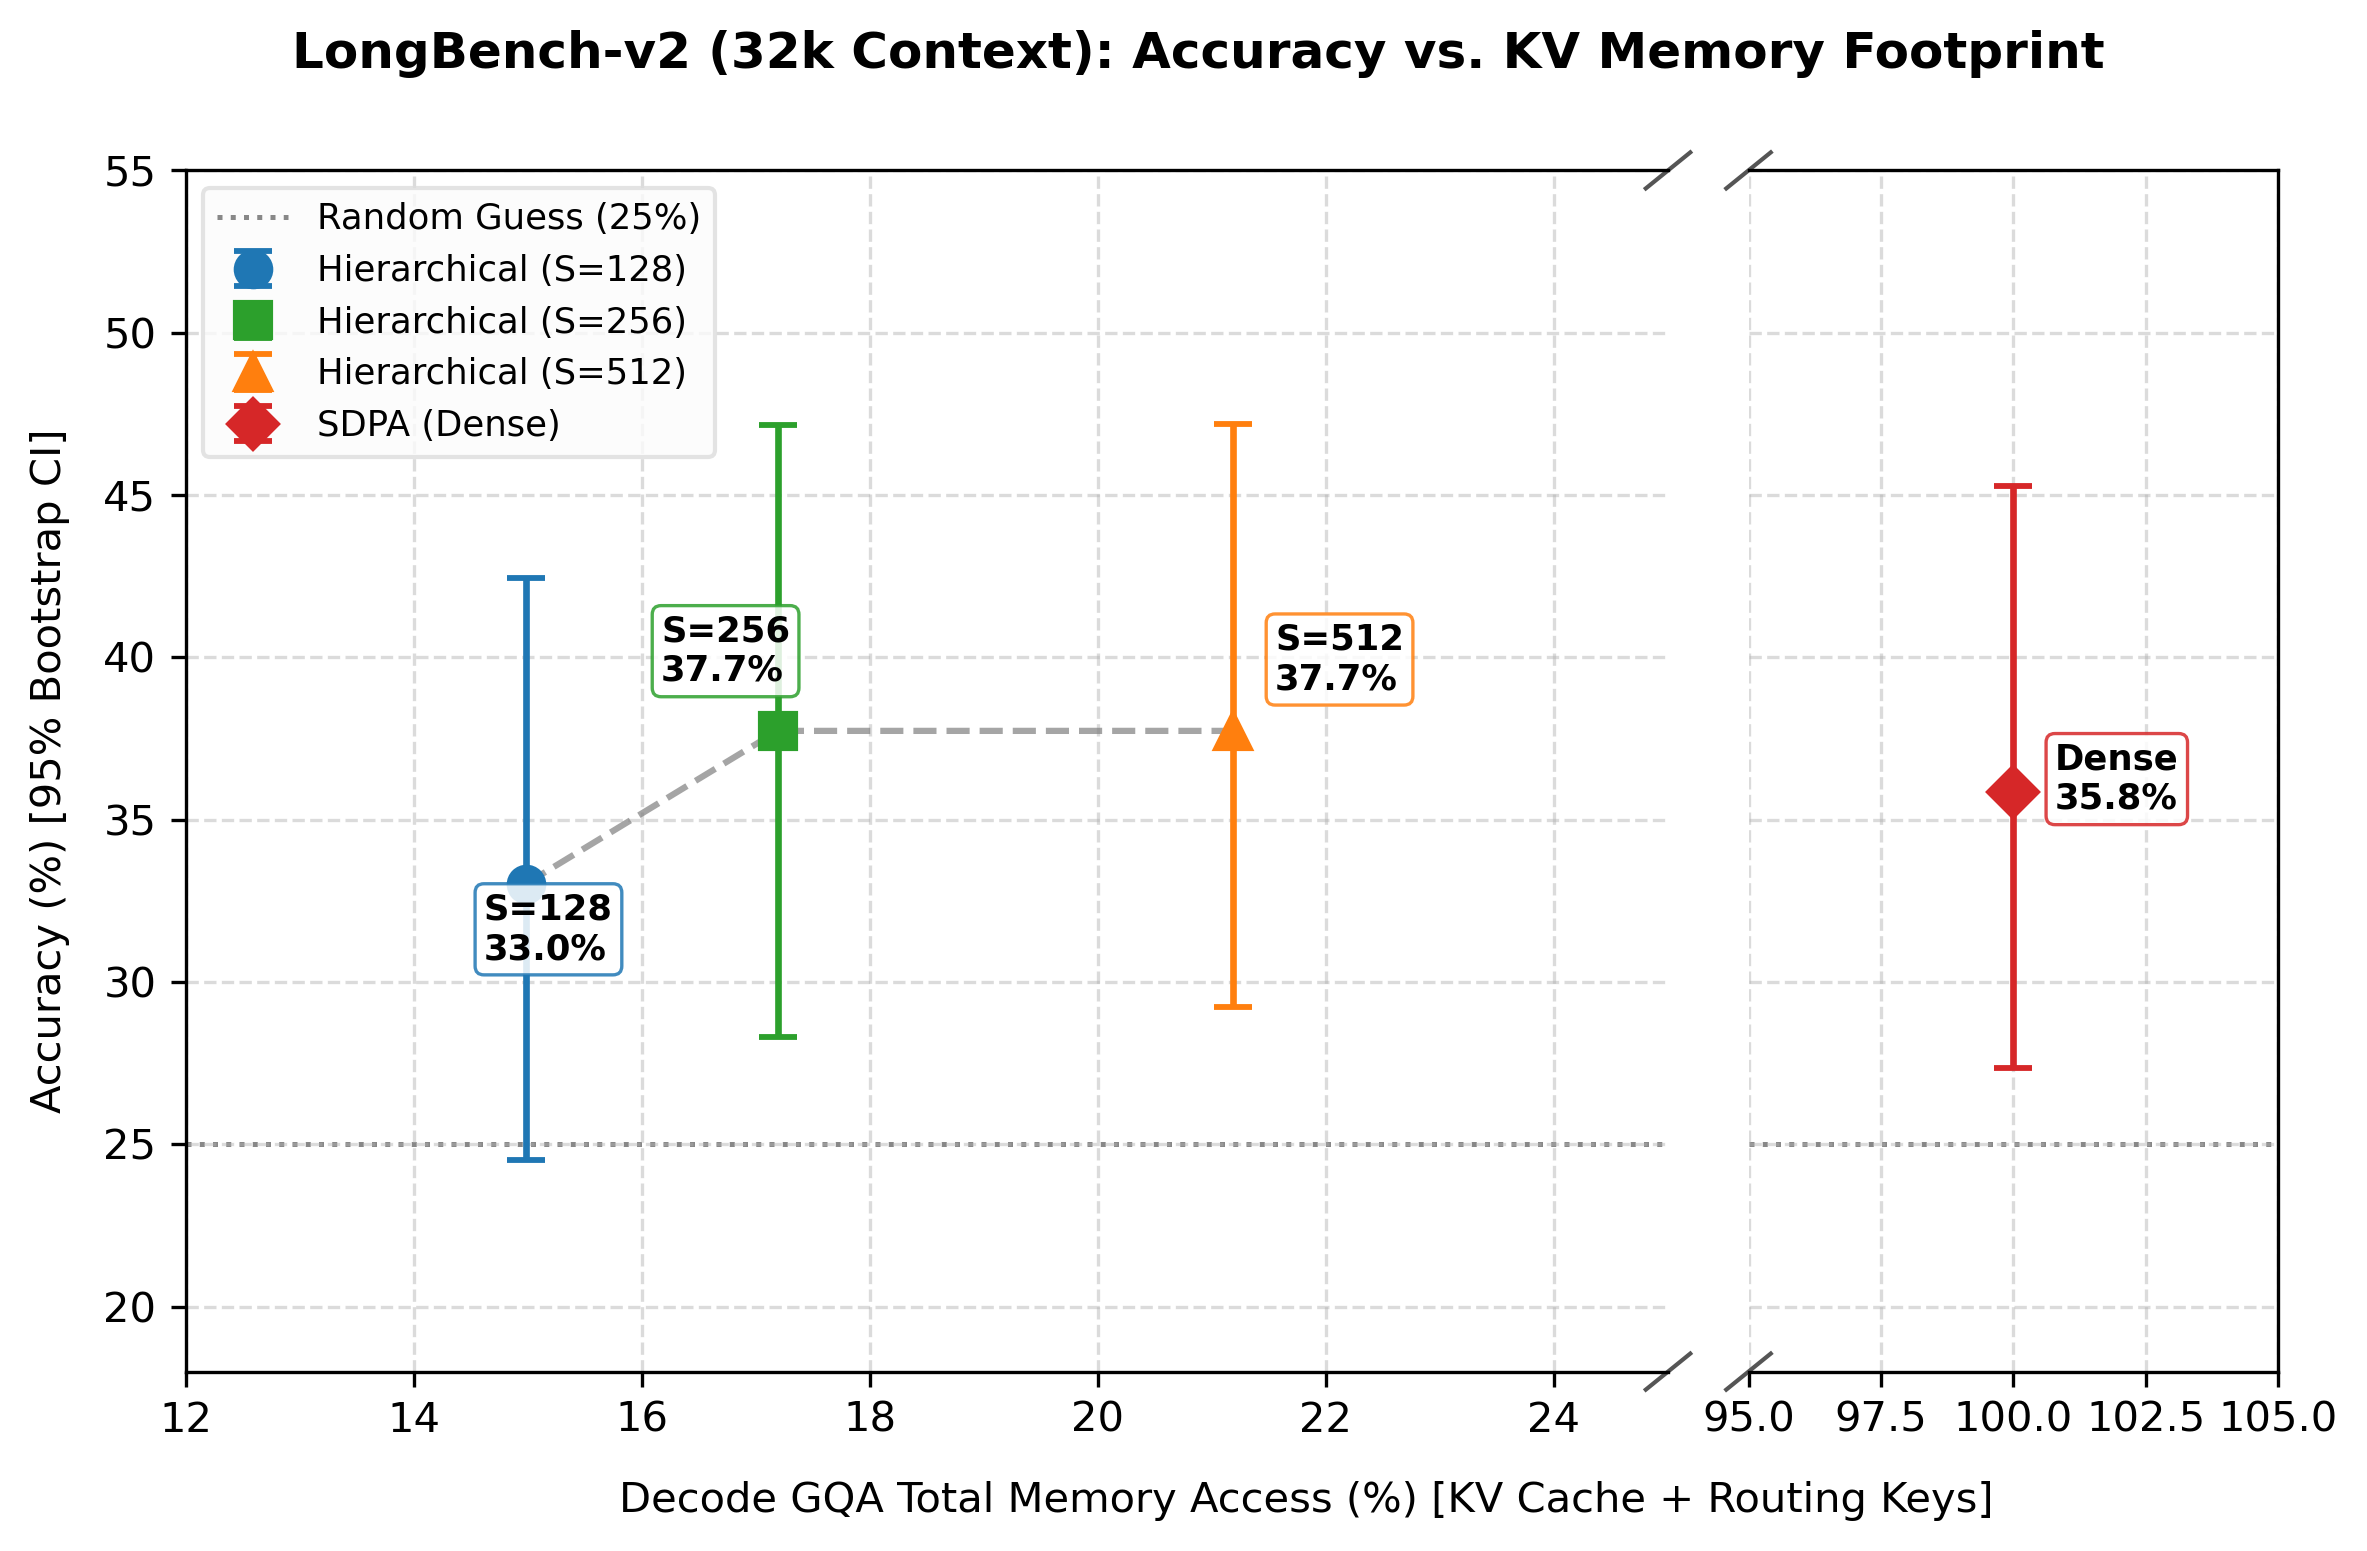

In [13]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  if not pred_text:
    return ""
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  return tail_matches[-1].upper() if tail_matches else ""


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0
  alpha = (1.0 - ci) / 2.0
  return np.percentile(means, 100.0 * alpha), np.percentile(
      means, 100.0 * (1.0 - alpha)
  )


eval_targets = [
    {
        "label": "Hierarchical (S=128)",
        "file": (
            "../benchmarks/longbench/hierarchical/128/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "o",
        "color": "#1f77b4",
        "tag": "S=128",
        "text_offset": (-10, -18),  # Shifted down-left
    },
    {
        "label": "Hierarchical (S=256)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "s",
        "color": "#2ca02c",
        "tag": "S=256",
        "text_offset": (-28, 12),  # Shifted up-left
    },
    {
        "label": "Hierarchical (S=512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": "^",
        "color": "#ff7f0e",
        "tag": "S=512",
        "text_offset": (10, 10),  # Shifted up-right
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
        "tag": "Dense",
        "text_offset": (10, -4),
    },
]

points = []
for target in eval_targets:
  if not os.path.exists(target["file"]):
    continue
  scores, access_pcts = [], []
  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt = meta_lookup[idx]["answer"]
      pred = extract_strict_mc_choice(entry.get("pred", ""))
      scores.append(1.0 if (pred and pred == gt) else 0.0)
      metrics = entry.get("metrics", {})
      access_pcts.append(
          metrics.get(
              "decode_gqa_total_access_pct",
              metrics.get("decode_naive_total_access_pct", 100.0),
          )
      )

  arr = np.array(scores)
  mean_acc = np.mean(arr) * 100.0
  low, high = bootstrap_ci(arr)
  points.append({
      "label": target["label"],
      "tag": target["tag"],
      "acc": mean_acc,
      "err": [[mean_acc - low], [high - mean_acc]],
      "access": np.mean(access_pcts),
      "marker": target["marker"],
      "color": target["color"],
      "offset": target["text_offset"],
  })

# 2. Broken-axis subplots (Left = Sparse zoom, Right = Dense baseline)
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(9, 5.2),
    dpi=300,
    gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08},
)

# Plot elements on both axes
for ax in (ax1, ax2):
  ax.grid(True, linestyle="--", alpha=0.45, zorder=0)
  ax.axhline(
      25.0,
      color="#888888",
      linestyle=":",
      linewidth=1.2,
      label="Random Guess (25%)",
      zorder=1,
  )

# Draw sparse trajectory curve on left axis
hier_pts = [p for p in points if "Hierarchical" in p["label"]]
hier_pts.sort(key=lambda x: x["access"])
ax1.plot(
    [p["access"] for p in hier_pts],
    [p["acc"] for p in hier_pts],
    color="#7f7f7f",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    zorder=2,
)

# Scatter points with customized callout tags
for p in points:
  target_ax = ax1 if p["access"] < 50 else ax2
  target_ax.errorbar(
      p["access"],
      p["acc"],
      yerr=p["err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.6,
      capsize=4.5,
      capthick=1.4,
      markersize=8.5,
      label=p["label"],
      zorder=4,
  )

  # Text badge with clean background patch to prevent bar occlusion
  target_ax.annotate(
      f"{p['tag']}\n{p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=p["offset"],
      fontsize=8.5,
      fontweight="semibold",
      bbox=dict(
          boxstyle="round,pad=0.25",
          facecolor="white",
          edgecolor=p["color"],
          alpha=0.85,
          linewidth=0.8,
      ),
      zorder=5,
  )

# Set axis boundaries
ax1.set_xlim(12, 25)  # Zooms into the sparse cluster
ax2.set_xlim(95, 105)  # Targets 100% SDPA
ax1.set_ylim(18, 55)

# Broken axis visual cues (diagonal slashes)
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False)

d = 0.015
kwargs = dict(
    transform=ax1.transAxes, color="#555555", clip_on=False, linewidth=1.0
)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 2.8, +d * 2.8), (-d, +d), **kwargs)
ax2.plot((-d * 2.8, +d * 2.8), (1 - d, 1 + d), **kwargs)

# Titles and labels
fig.suptitle(
    "LongBench-v2 (32k Context): Accuracy vs. KV Memory Footprint",
    fontsize=12,
    fontweight="bold",
    y=0.97,
)
ax1.set_ylabel("Accuracy (%) [95% Bootstrap CI]", fontsize=10, labelpad=8)
fig.text(
    0.54,
    0.02,
    "Decode GQA Total Memory Access (%) [KV Cache + Routing Keys]",
    ha="center",
    fontsize=10,
)

# Clean legend on left plot
handles, labels = ax1.get_legend_handles_labels()
# Add Dense SDPA handle from ax2
h2, l2 = ax2.get_legend_handles_labels()
for h, l in zip(h2, l2):
  if l not in labels:
    handles.append(h)
    labels.append(l)

ax1.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8.5,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("accuracy_vs_memory_readable.png")
print("Readable plot saved to accuracy_vs_memory_readable.png")

C:\Users\theep\AppData\Local\Temp\ipykernel_29920\3282571465.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


Saved to accuracy_vs_memory_unified_hierarchical.png


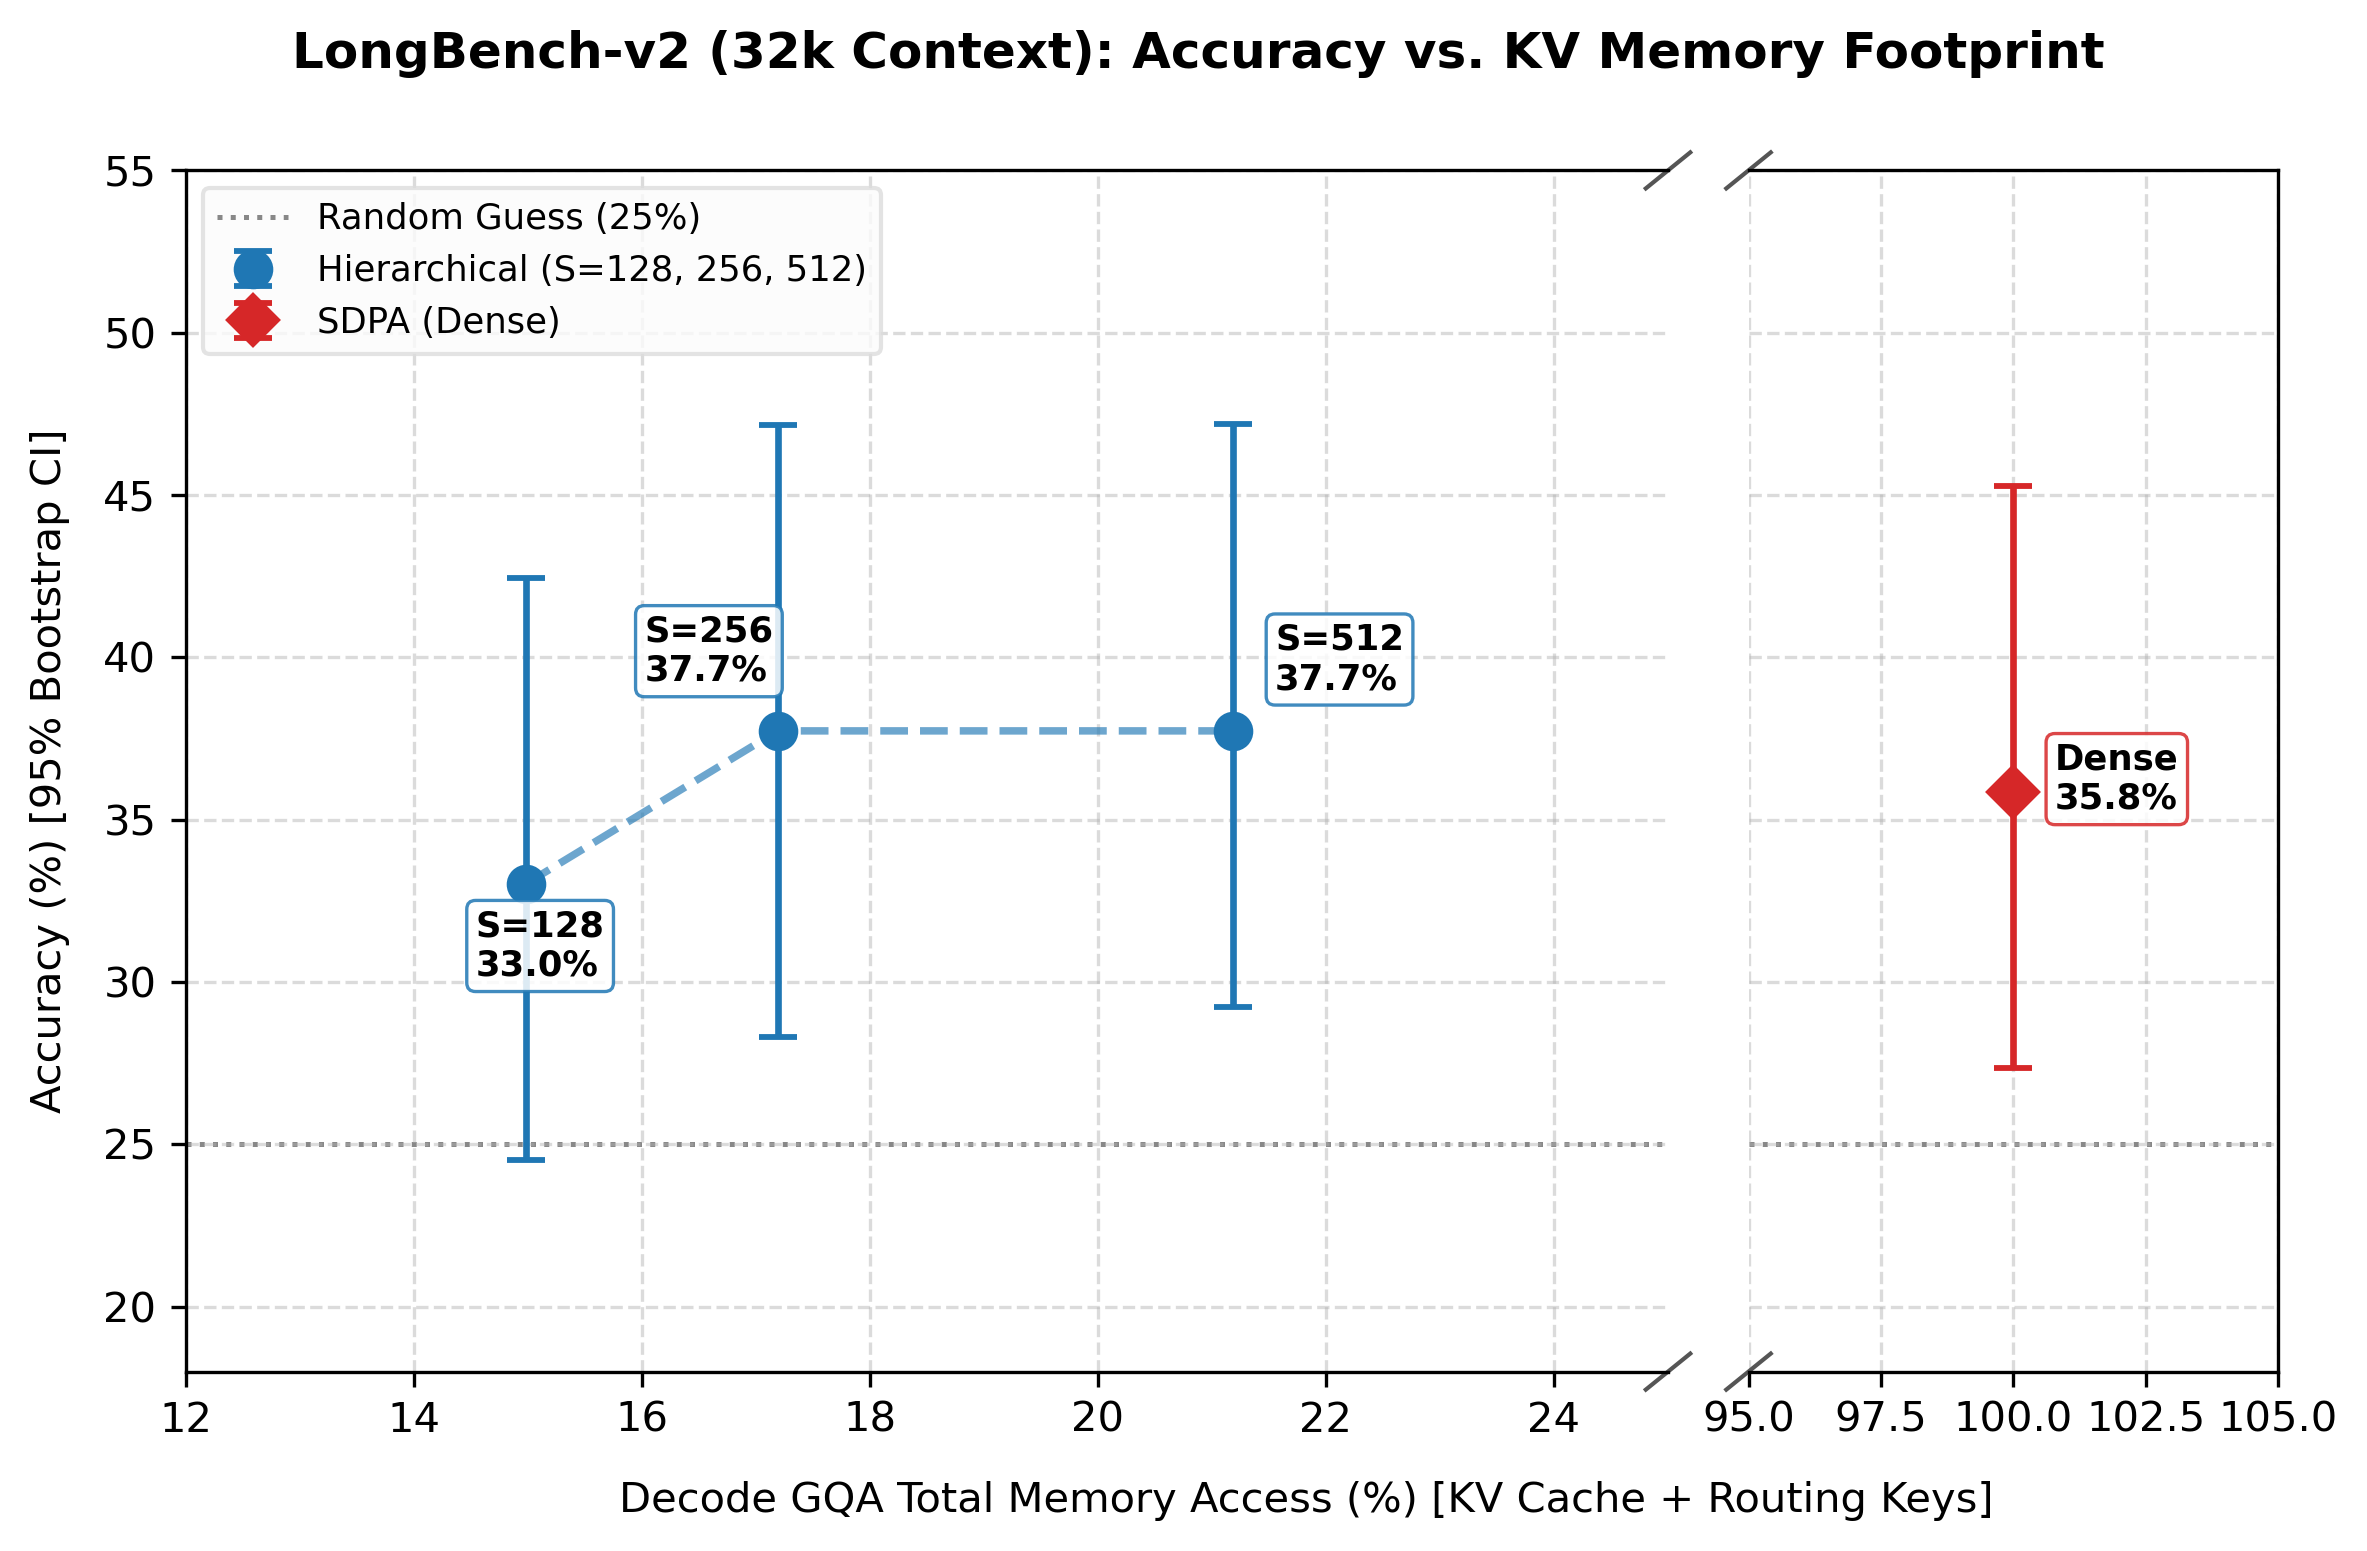

In [ ]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Metadata setup
with open("ground_truth_metadata_106.json", "r", encoding="utf-8") as f:
  meta_lookup = {int(k): v for k, v in json.load(f).items()}


def extract_strict_mc_choice(pred_text: str) -> str:
  if not pred_text:
    return ""
  final_match = re.search(
      r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
      pred_text,
      re.IGNORECASE,
  )
  if final_match:
    post_match_slice = pred_text[final_match.start() : final_match.end() + 10]
    if re.search(
        r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
        post_match_slice,
        re.IGNORECASE,
    ):
      return ""
    return final_match.group(1).upper()
  explicit_match = re.search(
      r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
      pred_text,
      re.IGNORECASE,
  )
  if explicit_match:
    return explicit_match.group(1).upper()
  tail_matches = re.findall(
      r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
  )
  return tail_matches[-1].upper() if tail_matches else ""


def bootstrap_ci(
    data: np.ndarray,
    n_bootstraps: int = 2000,
    ci: float = 0.95,
    seed: int = 2026,
):
  rng = np.random.default_rng(seed)
  resamples = rng.choice(data, size=(n_bootstraps, len(data)), replace=True)
  means = np.mean(resamples, axis=1) * 100.0
  alpha = (1.0 - ci) / 2.0
  return np.percentile(means, 100.0 * alpha), np.percentile(
      means, 100.0 * (1.0 - alpha)
  )


# Shared styling parameters
HIER_COLOR = "#1f77b4"
HIER_MARKER = "o"

eval_targets = [
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/1024/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=128",
        "text_offset": (-12, -22),
        "is_first_hier": True,
    },
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/256/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=256",
        "text_offset": (-32, 12),
        "is_first_hier": False,
    },
    {
        "label": "Hierarchical (S=128, 256, 512)",
        "file": (
            "../benchmarks/longbench/hierarchical/512/predictions/hierarchical/longbench_v2_cot.jsonl"
        ),
        "marker": HIER_MARKER,
        "color": HIER_COLOR,
        "tag": "S=512",
        "text_offset": (10, 10),
        "is_first_hier": False,
    },
    {
        "label": "SDPA (Dense)",
        "file": (
            "../benchmarks/longbench/sdpa/predictions/sdpa/longbench_v2_cot.jsonl"
        ),
        "marker": "D",
        "color": "#d62728",
        "tag": "Dense",
        "text_offset": (10, -4),
        "is_first_hier": False,
    },
]

points = []
for target in eval_targets:
  if not os.path.exists(target["file"]):
    continue
  scores, access_pcts = [], []
  with open(target["file"], "r", encoding="utf-8") as f:
    for line in f:
      if not line.strip():
        continue
      entry = json.loads(line.strip())
      idx = entry.get(
          "index",
          entry.get("others", {}).get(
              "source_position", entry.get("others", {}).get("id")
          ),
      )
      gt = meta_lookup[idx]["answer"]
      pred = extract_strict_mc_choice(entry.get("pred", ""))
      scores.append(1.0 if (pred and pred == gt) else 0.0)
      metrics = entry.get("metrics", {})
      access_pcts.append(
          metrics.get(
              "decode_gqa_total_access_pct",
              metrics.get("decode_naive_total_access_pct", 100.0),
          )
      )

  arr = np.array(scores)
  mean_acc = np.mean(arr) * 100.0
  low, high = bootstrap_ci(arr)
  points.append({
      "label": target["label"],
      "tag": target["tag"],
      "acc": mean_acc,
      "err": [[mean_acc - low], [high - mean_acc]],
      "access": np.mean(access_pcts),
      "marker": target["marker"],
      "color": target["color"],
      "offset": target["text_offset"],
      "is_first_hier": target["is_first_hier"],
  })

# 2. Broken-axis layout
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(9, 5.2),
    dpi=300,
    gridspec_kw={"width_ratios": [2.8, 1], "wspace": 0.08},
)

for ax in (ax1, ax2):
  ax.grid(True, linestyle="--", alpha=0.45, zorder=0)
  ax.axhline(
      25.0,
      color="#888888",
      linestyle=":",
      linewidth=1.2,
      label="Random Guess (25%)",
      zorder=1,
  )

# Draw connecting trajectory for hierarchical series
hier_pts = [p for p in points if "Hierarchical" in p["label"]]
hier_pts.sort(key=lambda x: x["access"])
ax1.plot(
    [p["access"] for p in hier_pts],
    [p["acc"] for p in hier_pts],
    color=HIER_COLOR,
    linestyle="--",
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)

# Plot points
for p in points:
  target_ax = ax1 if p["access"] < 50 else ax2
  # Only assign a label to the first hierarchical point to avoid duplicate legend entries
  label = (
      p["label"]
      if (p["is_first_hier"] or "Hierarchical" not in p["label"])
      else None
  )

  target_ax.errorbar(
      p["access"],
      p["acc"],
      yerr=p["err"],
      fmt=p["marker"],
      color=p["color"],
      ecolor=p["color"],
      elinewidth=1.6,
      capsize=4.5,
      capthick=1.4,
      markersize=8.5,
      label=label,
      zorder=4,
  )

  # Badge annotation
  target_ax.annotate(
      f"{p['tag']}\n{p['acc']:.1f}%",
      (p["access"], p["acc"]),
      textcoords="offset points",
      xytext=p["offset"],
      fontsize=8.5,
      fontweight="semibold",
      bbox=dict(
          boxstyle="round,pad=0.25",
          facecolor="white",
          edgecolor=p["color"],
          alpha=0.85,
          linewidth=0.8,
      ),
      zorder=5,
  )

ax1.set_xlim(12, 25)
ax2.set_xlim(95, 105)
ax1.set_ylim(18, 55)

# Broken-axis spine styling
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(left=False)

d = 0.015
kwargs = dict(
    transform=ax1.transAxes, color="#555555", clip_on=False, linewidth=1.0
)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d * 2.8, +d * 2.8), (-d, +d), **kwargs)
ax2.plot((-d * 2.8, +d * 2.8), (1 - d, 1 + d), **kwargs)

fig.suptitle(
    "LongBench-v2 (32k Context): Accuracy vs. KV Memory Footprint",
    fontsize=12,
    fontweight="bold",
    y=0.97,
)
ax1.set_ylabel("Accuracy (%) [95% Bootstrap CI]", fontsize=10, labelpad=8)
fig.text(
    0.54,
    0.02,
    "Decode GQA Total Memory Access (%) [KV Cache + Routing Keys]",
    ha="center",
    fontsize=10,
)

# Merge handles from both axes for the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + [h for h, l in zip(handles2, labels2) if l not in labels1]
labels = labels1 + [l for l in labels2 if l not in labels1]

ax1.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8.5,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("accuracy_vs_memory_unified_hierarchical.png")
print("Saved to accuracy_vs_memory_unified_hierarchical.png")

In [4]:
import json
import os
import re
from collections import defaultdict
from datasets import load_dataset


# ==============================================================================
# 1. GROUND TRUTH / METADATA LOADER
# ==============================================================================
def load_ground_truth(
    local_meta_path="ground_truth_metadata_106.json",
    hf_dataset="MrBigBrane/longbench-v2-32k",
    hf_config="longbench-short",
    split="train",
):
    """Loads ground truth from a local JSON file if present, otherwise

    pulls directly from the Hugging Face dataset.
    """
    if os.path.exists(local_meta_path):
        print(f"Loading metadata from local file: {local_meta_path}")
        with open(local_meta_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
            # Normalize keys to strings for universal lookup
            return {str(k): v for k, v in raw.items()}

    print(f"Local file '{local_meta_path}' not found.")
    print(f"Fetching ground truth from Hugging Face: {hf_dataset}...")
    ds = load_dataset(hf_dataset, name=hf_config, split=split)
    meta_lookup = {}

    for idx, row in enumerate(ds):
        row_id = str(row.get("id", row.get("_id", idx)))
        ans = (
            str(
                row.get(
                    "answer",
                    row.get(
                        "answers",
                        row.get("output", row.get("target", "")),
                    ),
                )
            )
            .strip()
            .upper()
        )
        # Normalize list/array answers if formatted as ['A']
        if ans.startswith("[") and ans.endswith("]"):
            ans = ans.strip("[]'\" ")

        meta_lookup[row_id] = {
            "answer": ans,
            "difficulty": row.get("difficulty", "medium").lower(),
            "length": row.get("length", "medium").lower(),
            "task": row.get("task", "general"),
        }
        # Also map integer string index
        meta_lookup[str(idx)] = meta_lookup[row_id]

    print(f"Loaded {len(meta_lookup)} ground truth entries from Hugging Face.")
    return meta_lookup


# ==============================================================================
# 2. ROBUST MULTIPLE CHOICE EXTRACTOR
# ==============================================================================
def extract_strict_mc_choice(pred_text: str) -> str:
    """Strictly extracts multiple-choice letters (A, B, C, or D).

    Rejects ambiguous or hedged predictions like '[A/B]'.
    """
    if not pred_text or not isinstance(pred_text, str):
        return ""

    # 1. Primary Target: Strict 'Final Answer: [X]' or 'Final Answer: X'
    final_match = re.search(
        r"Final\s+Answer:\s*\[?\s*([A-D])\s*\]?(?:\.|\b)",
        pred_text,
        re.IGNORECASE,
    )
    if final_match:
        # Check for ambiguity like [B/C] or [A or B] right after the match
        post_match = pred_text[final_match.start() : final_match.end() + 12]
        if re.search(
            r"Final\s+Answer:\s*\[?\s*[A-D]\s*(?:/|or|,)\s*[A-D]",
            post_match,
            re.IGNORECASE,
        ):
            return ""  # Ambiguous guess
        return final_match.group(1).upper()

    # 2. Secondary Target: Explicit "The correct answer is (X)" or "Answer: X"
    explicit_match = re.search(
        r"(?:(?:correct|final)\s+answer(?:\s+is)?[:\s]+(?:\()?|answer[:\s]+(?:\()?|therefore[,\s]+(?:\()?)([A-D])(?:\)|\b|\.)",
        pred_text,
        re.IGNORECASE,
    )
    if explicit_match:
        return explicit_match.group(1).upper()

    # 3. Tertiary Target: Standalone option declaration on final lines
    tail_matches = re.findall(
        r"(?:\n|\A)\s*(?:\()?([A-D])(?:\)|\.)\s*$", pred_text.strip()
    )
    if tail_matches:
        return tail_matches[-1].upper()

    # 4. Fallback: Search for boxed answers (e.g., \boxed{A})
    boxed_match = re.search(r"\\boxed\{([A-D])\}", pred_text)
    if boxed_match:
        return boxed_match.group(1).upper()

    return ""


# ==============================================================================
# 3. RUN CONFIGURATION & EVALUATION
# ==============================================================================
target_runs = {
    "santapp-128": "../benchmarks/longbench/hierarchical/1024/predictions/hierarchical/longbench-short.jsonl",
    # "sdpa-baseline": "/workspace/runs/longbench-v2-sdpa-32k/predictions/sdpa/longbench-short.jsonl",
    # "hierarchical-128": "/workspace/runs/longbench-v2-hierarchical-32k/predictions/hierarchical/longbench-short.jsonl",
}

meta_lookup = load_ground_truth()

headers = [
    "Model",
    "Overall",
    "Easy",
    "Hard",
    "Short",
    "Medium",
    "Long",
    "Extracted_Rate",
    "Correct/Total",
]
rows = []

for name, filepath in target_runs.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at {filepath}")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                pred_data.append(json.loads(line))

    category_counts = defaultdict(int)
    category_correct = defaultdict(float)
    extracted_count = 0
    total_correct = 0

    for i, pred in enumerate(pred_data):
        # Resolve index via primary or nested dictionary keys
        idx_candidates = [
            str(pred.get("index")),
            str(pred.get("id")),
            str(pred.get("others", {}).get("source_position")),
            str(pred.get("others", {}).get("id")),
            str(i),
        ]

        meta = None
        for candidate in idx_candidates:
            if candidate and candidate in meta_lookup:
                meta = meta_lookup[candidate]
                break

        if not meta:
            continue

        target = meta["answer"].strip().upper()
        raw_pred = pred.get("pred", pred.get("prediction", ""))
        choice = extract_strict_mc_choice(raw_pred)

        is_correct = choice == target and choice != ""
        judge = 1.0 if is_correct else 0.0

        if choice:
            extracted_count += 1
        if is_correct:
            total_correct += 1

        # Difficulty metrics
        diff = meta.get("difficulty", "medium")
        category_counts[diff] += 1
        category_correct[diff] += judge

        # Length metrics
        length = meta.get("length", "medium")
        category_counts[length] += 1
        category_correct[length] += judge

    total = len(pred_data)
    if total == 0:
        continue

    def calc_pct(correct_key, total_key):
        cnt = category_counts[total_key]
        return (
            f"{round(100 * category_correct[correct_key] / cnt, 1)}%"
            if cnt
            else "N/A"
        )

    overall_pct = f"{round(100 * total_correct / total, 1)}%"
    easy_pct = calc_pct("easy", "easy")
    hard_pct = calc_pct("hard", "hard")
    short_pct = calc_pct("short", "short")
    med_pct = calc_pct("medium", "medium")
    long_pct = calc_pct("long", "long")
    extract_pct = f"{round(100 * extracted_count / total, 1)}%"

    rows.append(
        [
            name,
            overall_pct,
            easy_pct,
            hard_pct,
            short_pct,
            med_pct,
            long_pct,
            extract_pct,
            f"{total_correct}/{total}",
        ]
    )

# Format into TSV & aligned console output
col_widths = [
    max(len(str(val)) for val in col) for col in zip(headers, *rows)
] if rows else [10] * len(headers)
format_str = "  ".join([f"{{:<{w}}}" for w in col_widths])

print("\n" + "=" * 90)
print(format_str.format(*headers))
print("-" * 90)
for r in rows:
    print(format_str.format(*r))
print("=" * 90 + "\n")

# Save TSV formatted file
with open("result.txt", "w", encoding="utf-8") as f:
    f.write("\t".join(headers) + "\n")
    for r in rows:
        f.write("\t".join(r) + "\n")

print("Evaluation complete. Results saved to result.txt")

Loading metadata from local file: ground_truth_metadata_106.json

Model        Overall  Easy   Hard   Short  Medium  Long  Extracted_Rate  Correct/Total
------------------------------------------------------------------------------------------
santapp-128  10.1%    21.7%  30.2%  27.8%  16.7%   N/A   36.8%           51/503       

Evaluation complete. Results saved to result.txt


In [5]:
import os
import json
import re
from collections import defaultdict
from datasets import load_dataset


# ==============================================================================
# 1. GROUND TRUTH LOADER
# ==============================================================================
def load_ground_truth(
    local_meta_path="ground_truth_metadata_106.json",
    hf_dataset="MrBigBrane/longbench-v2-32k",
    hf_config="longbench-short",
    split="train",
):
    """
    Loads ground truth mapping from local metadata JSON if available,
    otherwise fetches metadata directly from the Hugging Face dataset.
    """
    if os.path.exists(local_meta_path):
        print(f"Loading metadata from local file: {local_meta_path}")
        with open(local_meta_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
            meta = {}
            for k, v in raw.items():
                meta[str(k)] = v
                try:
                    meta[int(k)] = v
                except ValueError:
                    pass
            return meta

    print(f"Local file '{local_meta_path}' not found.")
    print(f"Fetching ground truth from Hugging Face: {hf_dataset} ({hf_config})...")
    ds = load_dataset(hf_dataset, name=hf_config, split=split)
    meta = {}
    
    for idx, row in enumerate(ds):
        ans = str(
            row.get("answer")
            or (row.get("outputs")[0] if isinstance(row.get("outputs"), list) and row.get("outputs") else "")
            or row.get("output")
            or ""
        ).strip("[]'\" ").upper()

        entry = {
            "answer": ans,
            "difficulty": str(row.get("difficulty", "medium")).lower(),
            "length": str(row.get("length", "medium")).lower(),
        }

        # Register across all potential identifier variants
        meta[str(idx)] = entry
        meta[idx] = entry
        if "id" in row and row["id"] is not None:
            meta[str(row["id"])] = entry
        if "uid" in row and row["uid"] is not None:
            meta[str(row["uid"])] = entry

    print(f"Successfully loaded {len(ds)} ground truth records.")
    return meta


# ==============================================================================
# 2. STRICT ANTI-HEDGING EXTRACTOR
# ==============================================================================
def extract_strict_mc_choice(pred_text: str) -> str:
    """
    Strictly extracts a single multiple-choice letter (A, B, C, or D).
    Rejects:
      - Multi-letter hedging (e.g., [A/B], 'A or B', 'B and C', 'A, B')
      - Uncertainty qualifiers (e.g., 'maybe B', 'probably C', 'could be A')
      - Conflicting anchors within the same output
    """
    if not pred_text or not isinstance(pred_text, str):
        return ""

    clean_text = pred_text.strip()
    hedge_qualifiers = r"(?:maybe|perhaps|probably|likely|could\s+be|might\s+be|either|unclear\s+between)"

    # Tier 1: Explicit 'Final Answer: [X]' or 'Final Choice: X'
    final_matches = list(re.finditer(
        r"(?:Final\s+Answer|Final\s+Choice)\*{0,2}\s*[:\-]?\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if final_matches:
        for match in final_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            # Reject multi-option split or qualifier
            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        # Reject conflicting declared letters
        found_letters = {m.group(1).upper() for m in final_matches}
        if len(found_letters) > 1:
            return ""
        return final_matches[-1].group(1).upper()

    # Tier 2: Definitive conclusion phrasing (e.g., "The correct option is B")
    concl_matches = list(re.finditer(
        r"(?:(?:correct|best)\s+(?:option|choice|answer)\s+is|matches\s+option|best\s+matches\s+option)\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if concl_matches:
        for match in concl_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        found_letters = {m.group(1).upper() for m in concl_matches}
        if len(found_letters) > 1:
            return ""
        return concl_matches[-1].group(1).upper()

    # Tier 3: Secondary answer label: "Answer: [X]"
    ans_matches = list(re.finditer(
        r"(?:Answer|Option)\s*[:\-]\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if ans_matches:
        for match in ans_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        found_letters = {m.group(1).upper() for m in ans_matches}
        if len(found_letters) > 1:
            return ""
        return ans_matches[-1].group(1).upper()

    # Tier 4: LaTeX \boxed{X}
    boxed_matches = list(re.finditer(r"\\boxed\{([A-D])\}", clean_text))
    if boxed_matches:
        found_letters = {m.group(1).upper() for m in boxed_matches}
        if len(found_letters) == 1:
            return list(found_letters)[0]
        return ""

    # Tier 5: Strict tail line search (last standalone token)
    tail_lines = [line.strip() for line in clean_text.splitlines() if line.strip()]
    if tail_lines:
        last_line = tail_lines[-1]
        if re.search(hedge_qualifiers, last_line, re.IGNORECASE):
            return ""
        if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", last_line, re.IGNORECASE):
            return ""

        m = re.match(r"^[\*\_\[\(]*([A-D])[\*\_\]\)\.]*$", last_line)
        if m:
            return m.group(1).upper()

    return ""


# ==============================================================================
# 3. EVALUATION RUNNER
# ==============================================================================
target_runs = {
    "hierarchical-1024": "../benchmarks/longbench/hierarchical/1024/predictions/hierarchical/longbench-short.jsonl",
    # "santapp-128": "/workspace/runs/longbench-v2-santapp-32k/predictions/santapp/longbench-short.jsonl",
    # "sdpa": "../benchmarks/longbench/sdpa/predictions/sdpa/longbench-short.jsonl",
}

meta_lookup = load_ground_truth()

headers = [
    "Model",
    "Overall",
    "Easy",
    "Hard",
    "Short",
    "Medium",
    "Long",
    "Extracted_Rate",
    "Correct/Total",
]
rows = []

for name, filepath in target_runs.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at '{filepath}'")
        continue

    pred_data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                pred_data.append(json.loads(line))

    category_counts = defaultdict(int)
    category_correct = defaultdict(float)
    extracted_count = 0
    total_correct = 0
    unextracted_samples = []

    for i, pred in enumerate(pred_data):
        # Resolve index against registered keys
        idx_keys = [
            pred.get("index"),
            str(pred.get("index")),
            pred.get("uid"),
            str(pred.get("uid")),
            pred.get("others", {}).get("source_position"),
            pred.get("others", {}).get("id"),
            i,
            str(i),
        ]

        meta = None
        for k in idx_keys:
            if k is not None and k in meta_lookup:
                meta = meta_lookup[k]
                break

        if not meta:
            continue

        target = meta["answer"].strip().upper()
        raw_pred = pred.get("pred", pred.get("prediction", ""))
        choice = extract_strict_mc_choice(raw_pred)

        is_correct = (choice == target and choice != "")
        judge = 1.0 if is_correct else 0.0

        if choice:
            extracted_count += 1
        elif len(unextracted_samples) < 3:
            unextracted_samples.append((pred.get("index", i), raw_pred))

        if is_correct:
            total_correct += 1

        # Tally categorical metrics
        diff = meta.get("difficulty", "medium")
        category_counts[diff] += 1
        category_correct[diff] += judge

        length = meta.get("length", "medium")
        category_counts[length] += 1
        category_correct[length] += judge

    total = len(pred_data)
    if total == 0:
        continue

    def calc_pct(key):
        cnt = category_counts[key]
        return f"{round(100 * category_correct[key] / cnt, 1)}%" if cnt else "N/A"

    overall_pct = f"{round(100 * total_correct / total, 1)}%"
    easy_pct = calc_pct("easy")
    hard_pct = calc_pct("hard")
    short_pct = calc_pct("short")
    med_pct = calc_pct("medium")
    long_pct = calc_pct("long")
    extract_pct = f"{round(100 * extracted_count / total, 1)}%"

    rows.append([
        name,
        overall_pct,
        easy_pct,
        hard_pct,
        short_pct,
        med_pct,
        long_pct,
        extract_pct,
        f"{total_correct}/{total}",
    ])

    if unextracted_samples:
        print(f"\n[Diagnostic] Unextracted sample tails for {name}:")
        for sample_idx, sample_text in unextracted_samples:
            print(f"  --- Index {sample_idx} ---")
            print("  " + sample_text.strip()[-180:].replace("\n", "\n  "))

# Display formatted table
col_widths = [max(len(str(val)) for val in col) for col in zip(headers, *rows)] if rows else [12] * len(headers)
fmt = "  ".join([f"{{:<{w}}}" for w in col_widths])

print("\n" + "=" * 96)
print(fmt.format(*headers))
print("-" * 96)
for r in rows:
    print(fmt.format(*r))
print("=" * 96 + "\n")

# Save tab-delimited result summary
with open("result.txt", "w", encoding="utf-8") as f:
    f.write("\t".join(headers) + "\n")
    for r in rows:
        f.write("\t".join(r) + "\n")

print("Evaluation complete. Results written to result.txt")

Loading metadata from local file: ground_truth_metadata_106.json

[Diagnostic] Unextracted sample tails for hierarchical-1024:
  --- Index 61 ---
  t she committed the murder herself. Madame Daubreuil overheard the conversation between Paul Renauld and his wife and overheard Renauld's plans, which led her to take action. a. C.

Model              Overall  Easy   Hard   Short  Medium  Long  Extracted_Rate  Correct/Total
------------------------------------------------------------------------------------------------
hierarchical-1024  10.1%    21.7%  30.2%  27.8%  16.7%   N/A   36.8%           51/503       

Evaluation complete. Results written to result.txt


In [6]:
import os
import json
import re
from collections import defaultdict


def extract_strict_mc_choice(pred_text: str) -> str:
    """Strictly extracts single multiple-choice letter (A, B, C, or D).
    Rejects multi-letter splits, hedging phrases, and conflicting anchors.
    """
    if not pred_text or not isinstance(pred_text, str):
        return ""

    clean_text = pred_text.strip()
    hedge_qualifiers = r"(?:maybe|perhaps|probably|likely|could\s+be|might\s+be|either|unclear\s+between)"

    # Tier 1: Explicit 'Final Answer: [X]' or 'Final Choice: X'
    final_matches = list(re.finditer(
        r"(?:Final\s+Answer|Final\s+Choice)\*{0,2}\s*[:\-]?\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if final_matches:
        for match in final_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            # Reject hedge or split choices
            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        found_letters = {m.group(1).upper() for m in final_matches}
        if len(found_letters) > 1:
            return ""  # Conflicting anchors
        return final_matches[-1].group(1).upper()

    # Tier 2: Definitive conclusion statements
    concl_matches = list(re.finditer(
        r"(?:(?:correct|best)\s+(?:option|choice|answer)\s+is|matches\s+option|best\s+matches\s+option)\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if concl_matches:
        for match in concl_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        found_letters = {m.group(1).upper() for m in concl_matches}
        if len(found_letters) > 1:
            return ""
        return concl_matches[-1].group(1).upper()

    # Tier 3: Secondary answer declaration: "Answer: [X]"
    ans_matches = list(re.finditer(
        r"(?:Answer|Option)\s*[:\-]\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean_text,
        re.IGNORECASE
    ))
    if ans_matches:
        for match in ans_matches:
            post_window = clean_text[match.start():match.end() + 20]
            pre_window = clean_text[max(0, match.start() - 25):match.start()]

            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post_window, re.IGNORECASE):
                return ""
            if re.search(hedge_qualifiers, pre_window, re.IGNORECASE):
                return ""

        found_letters = {m.group(1).upper() for m in ans_matches}
        if len(found_letters) > 1:
            return ""
        return ans_matches[-1].group(1).upper()

    # Tier 4: LaTeX \boxed{X}
    boxed_matches = list(re.finditer(r"\\boxed\{([A-D])\}", clean_text))
    if boxed_matches:
        found_letters = {m.group(1).upper() for m in boxed_matches}
        if len(found_letters) == 1:
            return list(found_letters)[0]
        return ""

    # Tier 5: Strict tail line check
    tail_lines = [line.strip() for line in clean_text.splitlines() if line.strip()]
    if tail_lines:
        last_line = tail_lines[-1]
        if re.search(hedge_qualifiers, last_line, re.IGNORECASE):
            return ""
        if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", last_line, re.IGNORECASE):
            return ""

        m = re.match(r"^[\*\_\[\(]*([A-D])[\*\_\]\)\.]*$", last_line)
        if m:
            return m.group(1).upper()

    return ""


# ==============================================================================
# EVALUATE RUNS
# ==============================================================================
target_runs = {
    "hierarchical-1024": "../benchmarks/longbench/hierarchical/1024/predictions/hierarchical/longbench-short.jsonl",
    # Add other runs here:
    # "santapp-128": "/workspace/runs/longbench-v2-santapp-32k/predictions/santapp/longbench-short.jsonl",
}

headers = ["Model", "Overall_Acc", "Extracted_Rate", "Correct/Total", "Missing_GroundTruth"]
rows = []

for name, filepath in target_runs.items():
    if not os.path.exists(filepath):
        print(f"Skipping {name}: file not found at '{filepath}'")
        continue

    total = 0
    extracted_count = 0
    total_correct = 0
    missing_gt = 0

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            pred = json.loads(line)
            total += 1

            # 1. Resolve Ground Truth target from within the JSON record itself
            outputs_val = pred.get("outputs") or pred.get("output") or pred.get("answer")
            if isinstance(outputs_val, list) and len(outputs_val) > 0:
                target = str(outputs_val[0]).strip("[]'\" ").upper()
            elif isinstance(outputs_val, str):
                target = outputs_val.strip("[]'\" ").upper()
            else:
                target = ""

            if not target:
                missing_gt += 1

            # 2. Extract model prediction
            raw_pred = pred.get("pred", pred.get("prediction", ""))
            choice = extract_strict_mc_choice(raw_pred)

            if choice:
                extracted_count += 1

            if target and choice == target:
                total_correct += 1

    if total == 0:
        continue

    acc_pct = f"{round(100 * total_correct / total, 1)}%"
    extract_pct = f"{round(100 * extracted_count / total, 1)}%"

    rows.append([
        name,
        acc_pct,
        extract_pct,
        f"{total_correct}/{total}",
        str(missing_gt)
    ])

# Display Table
col_widths = [max(len(str(val)) for val in col) for col in zip(headers, *rows)] if rows else [15] * len(headers)
fmt = "  ".join([f"{{:<{w}}}" for w in col_widths])

print("\n" + "=" * 80)
print(fmt.format(*headers))
print("-" * 80)
for r in rows:
    print(fmt.format(*r))
print("=" * 80 + "\n")


Model              Overall_Acc  Extracted_Rate  Correct/Total  Missing_GroundTruth
--------------------------------------------------------------------------------
hierarchical-1024  32.0%        99.2%           161/503        0                  



[hierarchical S=128] Acc: 32.4% [28.4%, 36.6%] | GQA Access: 15.3%
[hierarchical S=256] Acc: 32.8% [29.0%, 37.2%] | GQA Access: 17.7%
[hierarchical S=512] Acc: 30.4% [26.6%, 34.4%] | GQA Access: 22.2%
[hierarchical S=1024] Acc: 32.0% [28.0%, 36.0%] | GQA Access: 29.5%
[santa S=128] Acc: 30.2% [26.4%, 34.4%] | GQA Access: 50.4%
[santa S=256] Acc: 33.8% [30.0%, 38.0%] | GQA Access: 50.6%
[santa S=512] Acc: 34.6% [30.6%, 39.0%] | GQA Access: 51.0%
[santapp S=128] Acc: 30.2% [26.2%, 34.4%] | GQA Access: 16.7%
[santapp S=256] Acc: 29.6% [25.8%, 34.0%] | GQA Access: 20.4%
[santapp S=512] Acc: 33.0% [28.8%, 37.4%] | GQA Access: 26.5%
[SDPA] Acc: 32.0% [28.2%, 36.0%] | GQA Access: 100.0%

Plot saved to: c:\Users\theep\OPUS Lab Notebooks\plotting\accuracy_vs_gqa_memory_access_bootstrap.png


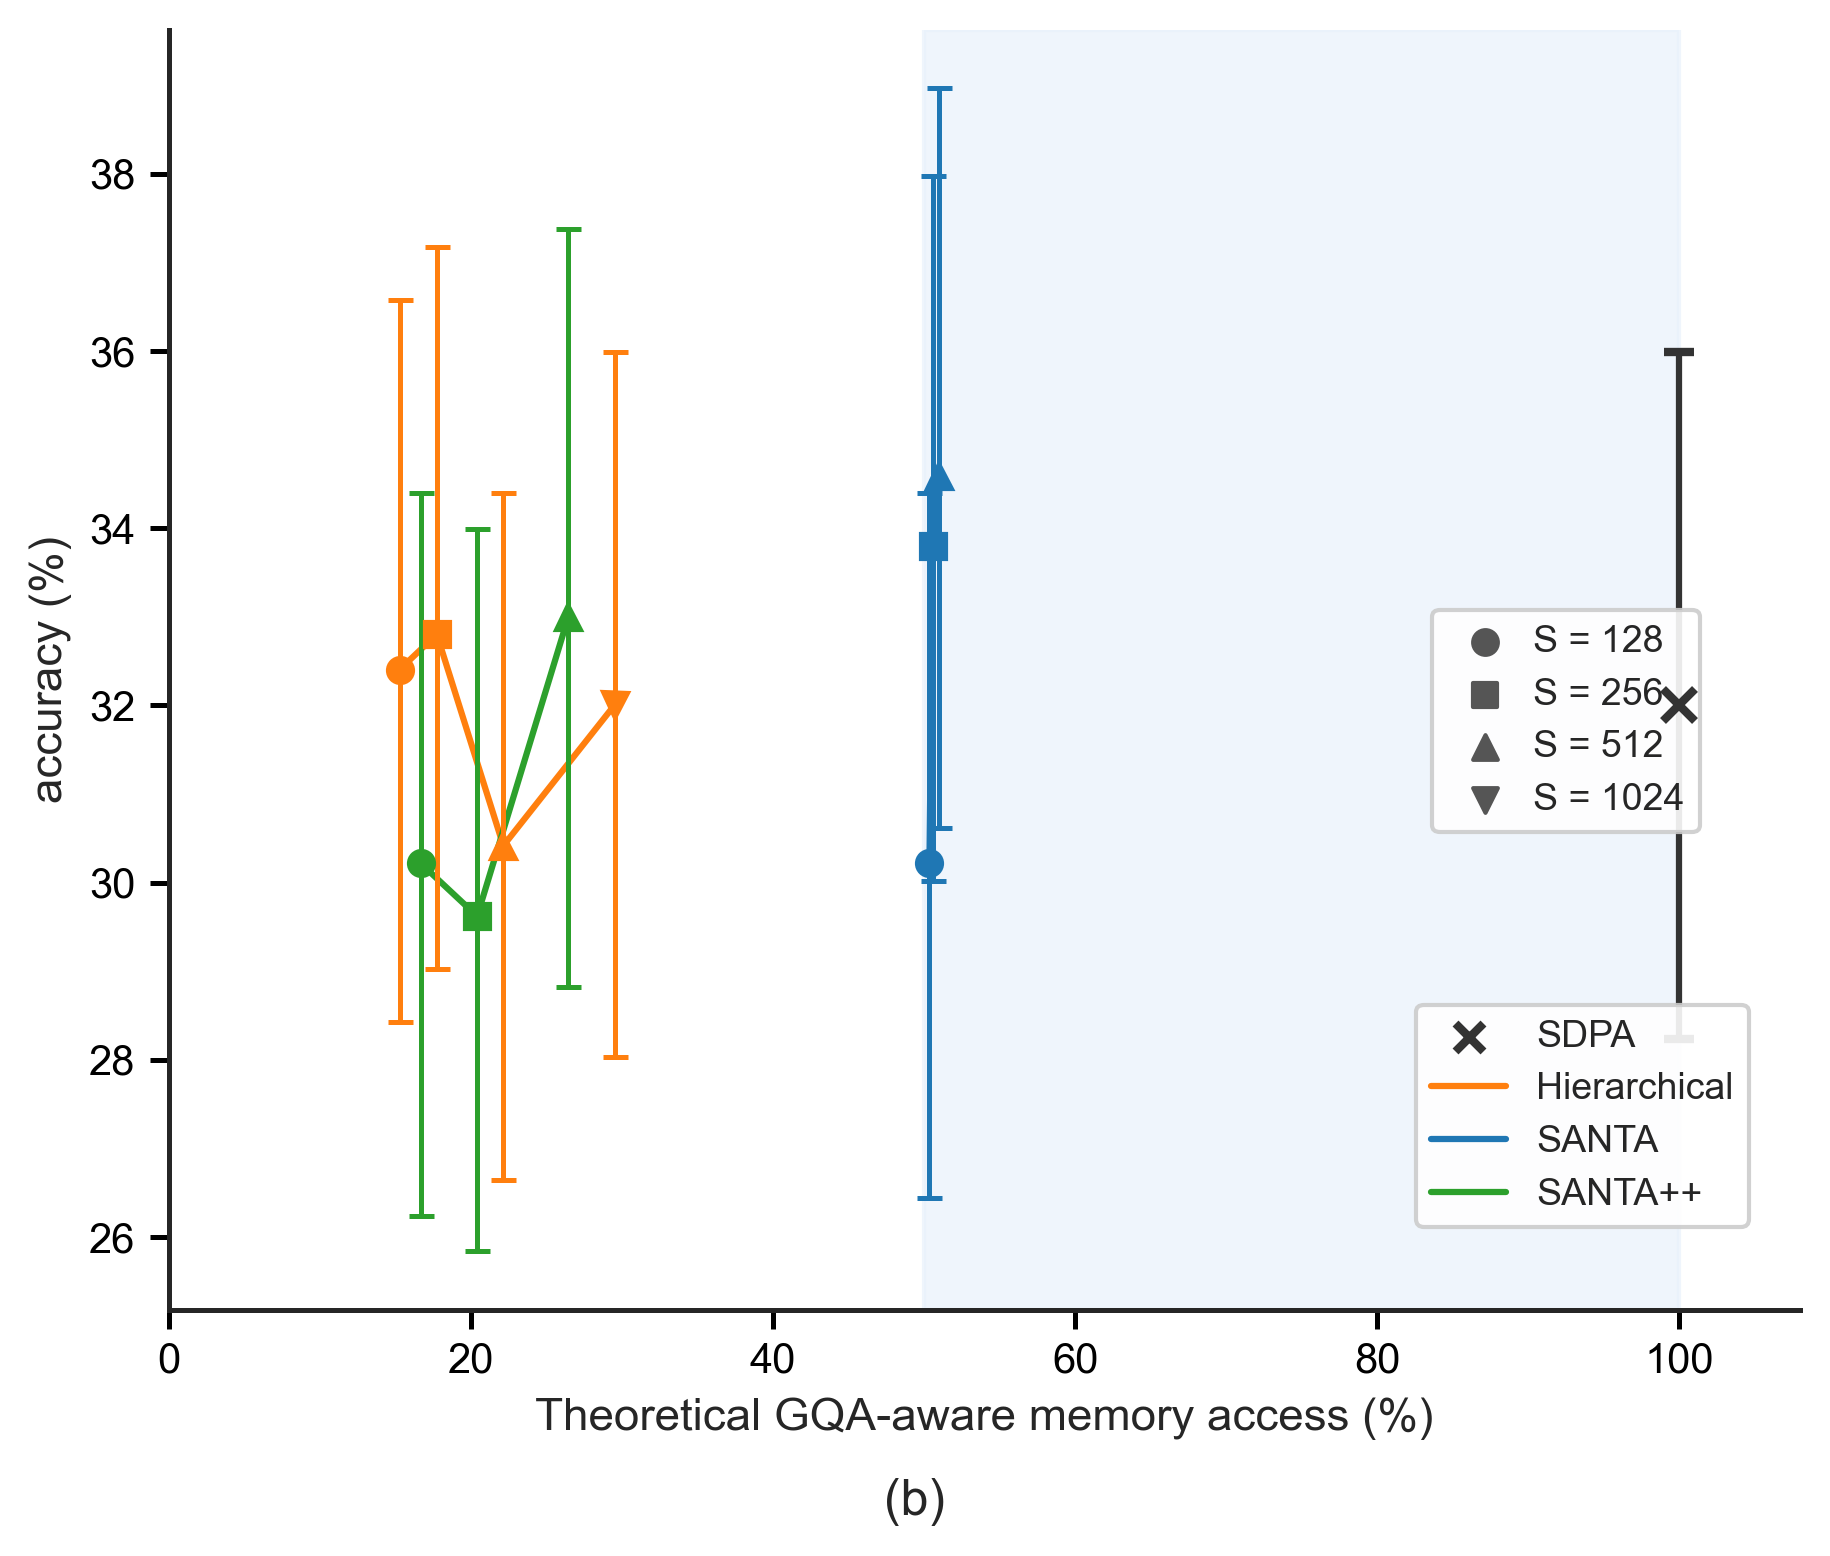

In [7]:
import glob
import json
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# 1. ACCURACY & METRICS EXTRACTION
# ==============================================================================
def extract_strict_mc_choice(pred_text: str) -> str:
    """Strict anti-hedging extractor for multiple-choice letters (A-D)."""
    if not pred_text or not isinstance(pred_text, str):
        return ""
    clean = pred_text.strip()
    hedge = r"(?:maybe|perhaps|probably|likely|could\s+be|might\s+be|either)"

    # Tier 1: Final Answer: [X]
    m = list(
        re.finditer(
            r"(?:Final\s+Answer|Final\s+Choice)\*{0,2}\s*[:\-]?\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
            clean,
            re.IGNORECASE,
        )
    )
    if m:
        for match in m:
            post = clean[match.start() : match.end() + 20]
            pre = clean[max(0, match.start() - 25) : match.start()]
            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[\*\_\[\(]*[A-D]", post, re.IGNORECASE):
                return ""
            if re.search(hedge, pre, re.IGNORECASE):
                return ""
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    # Tier 2: Explicit conclusions
    m = list(
        re.finditer(
            r"(?:(?:correct|best)\s+(?:option|choice|answer)\s+is|matches\s+option)\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
            clean,
            re.IGNORECASE,
        )
    )
    if m:
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    # Tier 3: Standalone tail line
    lines = [l.strip() for l in clean.splitlines() if l.strip()]
    if lines:
        match = re.match(r"^[\*\_\[\(]*([A-D])[\*\_\]\)\.]*$", lines[-1])
        if match:
            return match.group(1).upper()
    return ""


def compute_bootstrap_ci(correct_array: np.ndarray, n_bootstraps: int = 2000, seed: int = 42):
    """Computes empirical 95% bootstrap confidence interval for accuracy (%)."""
    rng = np.random.default_rng(seed)
    n = len(correct_array)
    # Resample with replacement: shape (n_bootstraps, n)
    boot_indices = rng.integers(0, n, size=(n_bootstraps, n))
    boot_accs = correct_array[boot_indices].mean(axis=1) * 100.0

    lower_ci = np.percentile(boot_accs, 2.5)
    upper_ci = np.percentile(boot_accs, 97.5)
    return lower_ci, upper_ci


def evaluate_jsonl(filepath: str, n_bootstraps: int = 2000):
    """Computes accuracy, 95% bootstrap CI, and mean GQA access (%) from JSONL."""
    if not os.path.exists(filepath):
        return None

    correct_list = []
    gqa_access_list = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            item = json.loads(line)

            # Ground truth target
            out = item.get("outputs") or item.get("output") or item.get("answer")
            target = (
                str(out[0] if isinstance(out, list) else out)
                .strip("[]'\" ")
                .upper()
            )

            # Prediction
            pred = item.get("pred", "")
            choice = extract_strict_mc_choice(pred)
            is_correct = 1 if (choice and target and choice == target) else 0
            correct_list.append(is_correct)

            # Metrics
            metrics = item.get("metrics", {})
            gqa_pct = metrics.get(
                "decode_gqa_total_access_pct",
                metrics.get("decode_gqa_kv_access_pct", None),
            )
            if gqa_pct is not None:
                gqa_access_list.append(float(gqa_pct))

    if not correct_list:
        return None

    correct_arr = np.array(correct_list, dtype=np.float32)
    acc = float(np.mean(correct_arr)) * 100.0

    # 95% bootstrap percentile confidence interval
    lower_ci, upper_ci = compute_bootstrap_ci(correct_arr, n_bootstraps=n_bootstraps)
    err_low = acc - lower_ci
    err_high = upper_ci - acc

    mean_gqa = float(np.mean(gqa_access_list)) if gqa_access_list else 100.0

    return {
        "accuracy": acc,
        "err_low": err_low,
        "err_high": err_high,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
        "gqa_access": mean_gqa,
    }


# ==============================================================================
# 2. RUN DISCOVERY & DATA COLLECTION
# ==============================================================================
BASE_DIR = r"C:\Users\theep\OPUS Lab Notebooks\benchmarks\longbench"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "benchmarks/longbench"

variants = ["hierarchical", "santa", "santapp"]
sample_budgets = [128, 256, 512, 1024]

run_data = defaultdict(dict)

# Collect variant data
for var in variants:
    for s in sample_budgets:
        pattern = os.path.join(
            BASE_DIR, var, str(s), "predictions", var, "longbench-short.jsonl"
        )
        matches = glob.glob(pattern)
        if not matches:
            pattern = os.path.join(
                BASE_DIR, var, str(s), "predictions", "*", "*.jsonl"
            )
            matches = glob.glob(pattern)

        if matches:
            res = evaluate_jsonl(matches[0])
            if res:
                run_data[var][s] = res
                print(
                    f"[{var} S={s}] Acc: {res['accuracy']:.1f}% "
                    f"[{res['lower_ci']:.1f}%, {res['upper_ci']:.1f}%] | "
                    f"GQA Access: {res['gqa_access']:.1f}%"
                )

# Collect baseline SDPA
sdpa_matches = glob.glob(
    os.path.join(
        BASE_DIR, "sdpa", "predictions", "sdpa", "longbench-short.jsonl"
    )
)
sdpa_res = evaluate_jsonl(sdpa_matches[0]) if sdpa_matches else None
if sdpa_res:
    sdpa_res["gqa_access"] = 100.0
    print(
        f"[SDPA] Acc: {sdpa_res['accuracy']:.1f}% "
        f"[{sdpa_res['lower_ci']:.1f}%, {sdpa_res['upper_ci']:.1f}%] | "
        f"GQA Access: {sdpa_res['gqa_access']:.1f}%"
    )


# ==============================================================================
# 3. PLOT GENERATION WITH ASYMMETRIC 95% BOOTSTRAP CI
# ==============================================================================
plt.style.use("seaborn-v0_8-white" if "seaborn-v0_8-white" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(6.2, 5.0), dpi=300)

color_map = {
    "santa": "#1f77b4",       # Blue
    "santapp": "#2ca02c",     # Green
    "hierarchical": "#ff7f0e",# Orange
}
label_map = {
    "santa": "SANTA",
    "santapp": "SANTA++",
    "hierarchical": "Hierarchical",
}
marker_map = {
    128: "o",
    256: "s",
    512: "^",
    1024: "v",
    2048: "P",
    4096: "*",
}

# 1. Shaded region (e.g. >50% access budget)
ax.axvspan(50, 100, color="#e9f2fb", alpha=0.7, zorder=1)

# 2. Plot curves with 95% Bootstrap Error Bars
for var in variants:
    budgets = sorted(run_data[var].keys())
    if not budgets:
        continue

    x_vals = [run_data[var][s]["gqa_access"] for s in budgets]
    y_vals = [run_data[var][s]["accuracy"] for s in budgets]
    y_err_low = [run_data[var][s]["err_low"] for s in budgets]
    y_err_high = [run_data[var][s]["err_high"] for s in budgets]

    c = color_map.get(var, "#333333")

    # Connect variant curve
    ax.plot(x_vals, y_vals, color=c, linewidth=1.5, zorder=3)

    # Plot markers with asymmetric 95% bootstrap error bars: [[lows...], [highs...]]
    for s, x, y, el, eh in zip(budgets, x_vals, y_vals, y_err_low, y_err_high):
        m = marker_map.get(s, "o")
        ax.errorbar(
            x,
            y,
            yerr=[[el], [eh]],
            fmt=m,
            color=c,
            ecolor=c,
            elinewidth=1.2,
            capsize=3.0,
            capthick=1.2,
            markersize=6.0,
            zorder=4,
        )

# 3. Plot SDPA baseline with bootstrap CI
if sdpa_res:
    ax.errorbar(
        sdpa_res["gqa_access"],
        sdpa_res["accuracy"],
        yerr=[[sdpa_res["err_low"]], [sdpa_res["err_high"]]],
        fmt="x",
        color="#333333",
        ecolor="#333333",
        elinewidth=1.5,
        capsize=3.5,
        capthick=1.5,
        markersize=7.5,
        markeredgewidth=2.0,
        zorder=5,
    )

# Axis labels & styling
ax.set_xlabel(
    "Theoretical GQA-aware memory access (%)", fontsize=11, fontweight="medium"
)
ax.set_ylabel("accuracy (%)", fontsize=11, fontweight="medium")
ax.set_xlim(0, 108)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(
    direction="out", length=4.5, width=1.2, colors="black", labelsize=10
)

# ------------------------------------------------------------------------------
# 4. DUAL LEGENDS
# ------------------------------------------------------------------------------
# Top legend: Sample Budget Markers
marker_handles = []
marker_labels = []
for s in sample_budgets:
    if any(s in run_data[var] for var in variants):
        h = ax.scatter(
            [],
            [],
            marker=marker_map[s],
            color="#555555",
            s=35,
            label=f"S = {s}",
        )
        marker_handles.append(h)
        marker_labels.append(f"S = {s}")

legend1 = ax.legend(
    handles=marker_handles,
    labels=marker_labels,
    loc="center right",
    bbox_to_anchor=(0.95, 0.46),
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    fontsize=9,
    handletextpad=0.3,
)
ax.add_artist(legend1)

# Bottom legend: Model Variants & SDPA
variant_handles = []
variant_labels = []
if sdpa_res:
    h_sdpa = ax.scatter(
        [],
        [],
        marker="x",
        color="#333333",
        s=45,
        linewidths=2.0,
        label="SDPA",
    )
    variant_handles.append(h_sdpa)
    variant_labels.append("SDPA")

for var in variants:
    if run_data[var]:
        line = plt.Line2D(
            [0], [0], color=color_map[var], lw=1.5, label=label_map[var]
        )
        variant_handles.append(line)
        variant_labels.append(label_map[var])

ax.legend(
    handles=variant_handles,
    labels=variant_labels,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.05),
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    fontsize=9,
)

fig.text(0.5, -0.02, "(b)", ha="center", fontsize=12)

plt.tight_layout()
output_filename = "accuracy_vs_gqa_memory_access_bootstrap.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"\nPlot saved to: {os.path.abspath(output_filename)}")
plt.show()

Plot saved successfully as PNG and PDF.


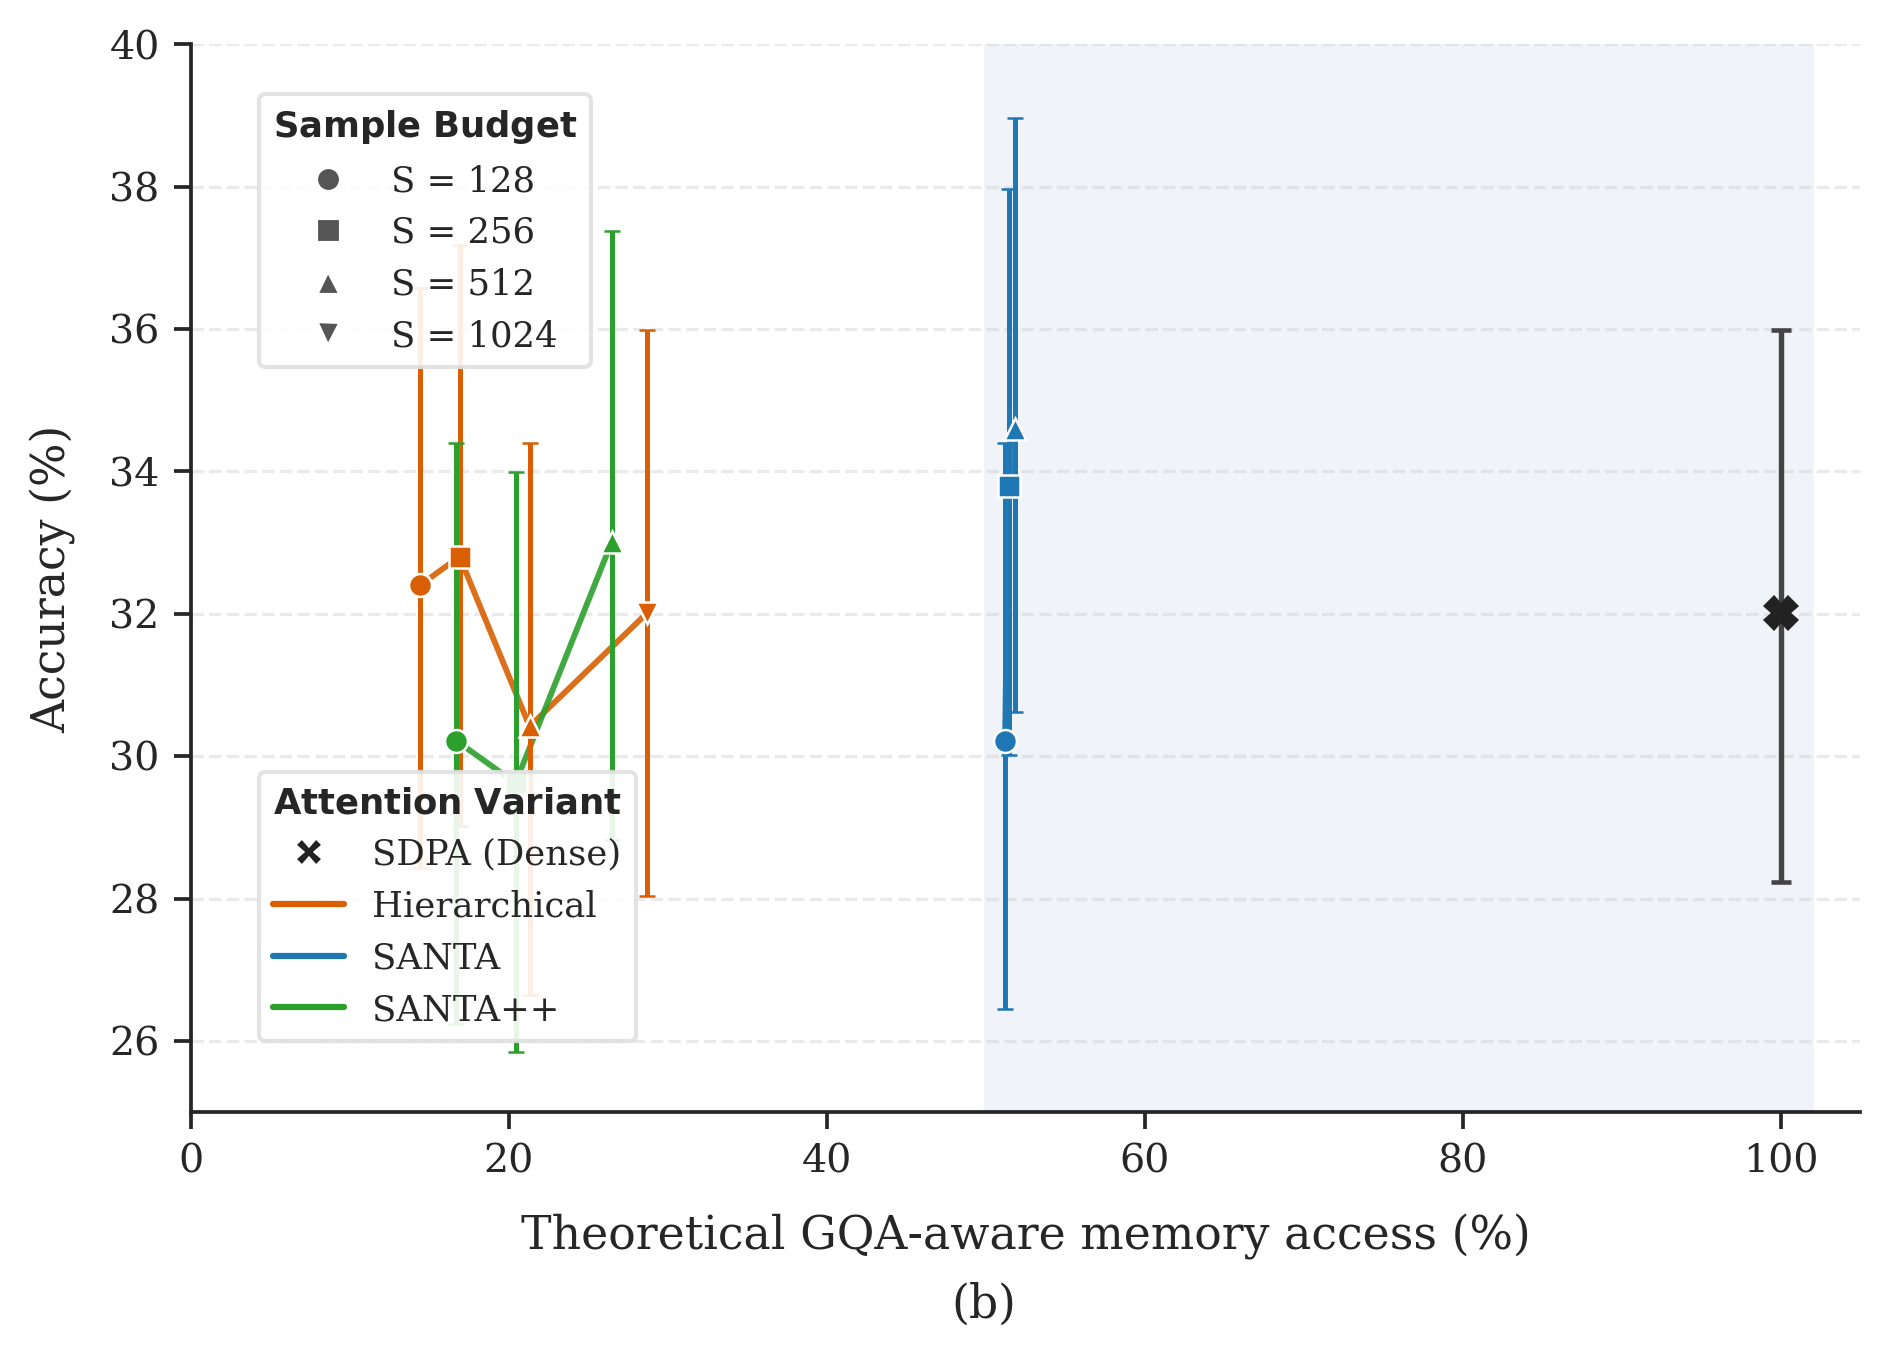

In [8]:
import os
import glob
import json
import re
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ACCURACY & METRICS EXTRACTION (with anti-hedging)
# ==============================================================================
def extract_strict_mc_choice(pred_text: str) -> str:
    if not pred_text or not isinstance(pred_text, str):
        return ""
    clean = pred_text.strip()
    hedge = r"(?:maybe|perhaps|probably|likely|could\s+be|might\s+be|either)"

    m = list(re.finditer(
        r"(?:Final\s+Answer|Final\s+Choice)\*{0,2}\s*[:\-]?\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean, re.IGNORECASE
    ))
    if m:
        for match in m:
            post = clean[match.start():match.end() + 20]
            pre = clean[max(0, match.start() - 25):match.start()]
            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[A-D]", post, re.IGNORECASE):
                return ""
            if re.search(hedge, pre, re.IGNORECASE):
                return ""
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    m = list(re.finditer(
        r"(?:(?:correct|best)\s+(?:option|choice|answer)\s+is|matches\s+option)\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
        clean, re.IGNORECASE
    ))
    if m:
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    lines = [l.strip() for l in clean.splitlines() if l.strip()]
    if lines:
        match = re.match(r"^[\*\_\[\(]*([A-D])[\*\_\]\)\.]*$", lines[-1])
        if match:
            return match.group(1).upper()
    return ""

def compute_bootstrap_ci(correct_array: np.ndarray, n_bootstraps: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = len(correct_array)
    boot_indices = rng.integers(0, n, size=(n_bootstraps, n))
    boot_accs = correct_array[boot_indices].mean(axis=1) * 100.0
    return np.percentile(boot_accs, 2.5), np.percentile(boot_accs, 97.5)

def evaluate_jsonl(filepath: str, n_bootstraps: int = 2000):
    if not os.path.exists(filepath):
        return None

    correct_list = []
    gqa_access_list = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            item = json.loads(line)
            out = item.get("outputs") or item.get("output") or item.get("answer")
            target = str(out[0] if isinstance(out, list) else out).strip("[]'\" ").upper()

            choice = extract_strict_mc_choice(item.get("pred", ""))
            correct_list.append(1 if (choice and target and choice == target) else 0)

            metrics = item.get("metrics", {})
            gqa_pct = metrics.get("decode_gqa_total_access_pct", metrics.get("decode_gqa_kv_access_pct", None))
            if gqa_pct is not None:
                gqa_access_list.append(float(gqa_pct))

    if not correct_list:
        return None

    correct_arr = np.array(correct_list, dtype=np.float32)
    acc = float(np.mean(correct_arr)) * 100.0
    lower_ci, upper_ci = compute_bootstrap_ci(correct_arr, n_bootstraps=n_bootstraps)

    return {
        "accuracy": acc,
        "err_low": acc - lower_ci,
        "err_high": upper_ci - acc,
        "gqa_access": float(np.mean(gqa_access_list)) if gqa_access_list else 100.0,
    }

# ==============================================================================
# 2. RUN DATA COLLECTION
# ==============================================================================
BASE_DIR = r"C:\Users\theep\OPUS Lab Notebooks\benchmarks\longbench"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "benchmarks/longbench"

variants = ["hierarchical", "santa", "santapp"]
sample_budgets = [128, 256, 512, 1024]
run_data = defaultdict(dict)

for var in variants:
    for s in sample_budgets:
        matches = glob.glob(os.path.join(BASE_DIR, var, str(s), "predictions", var, "longbench-short.jsonl"))
        if not matches:
            matches = glob.glob(os.path.join(BASE_DIR, var, str(s), "predictions", "*", "*.jsonl"))
        if matches:
            res = evaluate_jsonl(matches[0])
            if res:
                run_data[var][s] = res

sdpa_matches = glob.glob(os.path.join(BASE_DIR, "sdpa", "predictions", "sdpa", "longbench-short.jsonl"))
sdpa_res = evaluate_jsonl(sdpa_matches[0]) if sdpa_matches else None
if sdpa_res:
    sdpa_res["gqa_access"] = 100.0

# ==============================================================================
# 3. RESEARCH-GRADE VISUALIZATION
# ==============================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 8.5,
})

fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=300)

# Color scheme & styling matching publication guidelines
color_map = {
    "santa": "#1f77b4",       # Classical blue
    "santapp": "#2ca02c",     # Forest green
    "hierarchical": "#d95f02",# Burnt orange
}
label_map = {
    "santa": "SANTA",
    "santapp": "SANTA++",
    "hierarchical": "Hierarchical",
}
marker_map = {
    128: "o",
    256: "s",
    512: "^",
    1024: "v",
}

# Horizontal offsets (dodging) to prevent overlapping bars
dodge_map = {
    "hierarchical": -0.85,
    "santapp": 0.0,
    "santa": 0.85,
}

# Background highlight for uncompressed/baseline memory access (>50%)
ax.axvspan(50, 102, color="#f0f4f9", zorder=0)

# Subtle horizontal grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.4, color="#cccccc", zorder=1)

# Plot curves & error bars
for var in variants:
    budgets = sorted(run_data[var].keys())
    if not budgets:
        continue

    raw_x = [run_data[var][s]["gqa_access"] for s in budgets]
    # Apply subtle jitter so overlapping curves remain readable
    x_vals = [x + dodge_map[var] for x in raw_x]
    y_vals = [run_data[var][s]["accuracy"] for s in budgets]
    y_err_low = [run_data[var][s]["err_low"] for s in budgets]
    y_err_high = [run_data[var][s]["err_high"] for s in budgets]

    c = color_map[var]

    # Clean connecting spline/line
    ax.plot(x_vals, y_vals, color=c, linewidth=1.4, alpha=0.9, zorder=3)

    # Markers and minimalist error bars (smaller capsize, lighter alpha)
    for s, x, y, el, eh in zip(budgets, x_vals, y_vals, y_err_low, y_err_high):
        ax.errorbar(
            x, y, yerr=[[el], [eh]],
            fmt=marker_map.get(s, "o"),
            color=c,
            ecolor=c,
            elinewidth=1.2,
            capsize=2.0,
            capthick=1.0,
            markersize=5.5,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4
        )

# Plot baseline SDPA
if sdpa_res:
    ax.errorbar(
        sdpa_res["gqa_access"], sdpa_res["accuracy"],
        yerr=[[sdpa_res["err_low"]], [sdpa_res["err_high"]]],
        fmt="X",
        color="#222222",
        ecolor="#444444",
        elinewidth=1.3,
        capsize=2.5,
        capthick=1.1,
        markersize=7.0,
        zorder=5
    )

# Spines and Axis bounds
ax.set_xlabel("Theoretical GQA-aware memory access (%)", fontweight="medium", labelpad=8)
ax.set_ylabel("Accuracy (%)", fontweight="medium", labelpad=8)
ax.set_xlim(0, 105)
ax.set_ylim(25, 40)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)
ax.tick_params(direction="out", length=4, width=0.9)

# ------------------------------------------------------------------------------
# CLEAN SINGLE/DUAL LEGEND
# ------------------------------------------------------------------------------
# Markers (Budgets)
marker_handles = [
    plt.Line2D([0], [0], marker=marker_map[s], color="w", markerfacecolor="#555555", markersize=6, label=f"S = {s}")
    for s in sample_budgets if any(s in run_data[v] for v in variants)
]
legend1 = ax.legend(
    handles=marker_handles,
    loc="upper left",
    bbox_to_anchor=(0.03, 0.97),
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.9,
    title=r"$\bf{Sample\ Budget}$",
    title_fontsize=8.5
)
ax.add_artist(legend1)

# Lines (Methods)
method_handles = []
if sdpa_res:
    method_handles.append(
        plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="#222222", markersize=7, label="SDPA (Dense)")
    )
for var in variants:
    if run_data[var]:
        method_handles.append(
            plt.Line2D([0], [0], color=color_map[var], lw=1.5, label=label_map[var])
        )

ax.legend(
    handles=method_handles,
    loc="lower left",
    bbox_to_anchor=(0.03, 0.05),
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.9,
    title=r"$\bf{Attention\ Variant}$",
    title_fontsize=8.5
)

fig.text(0.52, -0.01, "(b)", ha="center", fontsize=11, fontweight="medium")

plt.tight_layout()
plt.savefig("accuracy_vs_gqa_memory_access_clean.png", dpi=300, bbox_inches="tight")
plt.savefig("accuracy_vs_gqa_memory_access_clean.pdf", bbox_inches="tight")  # Vector PDF for LaTeX
print("Plot saved successfully as PNG and PDF.")
plt.show()

Saved cleanly formatted plot with zero data occlusion.


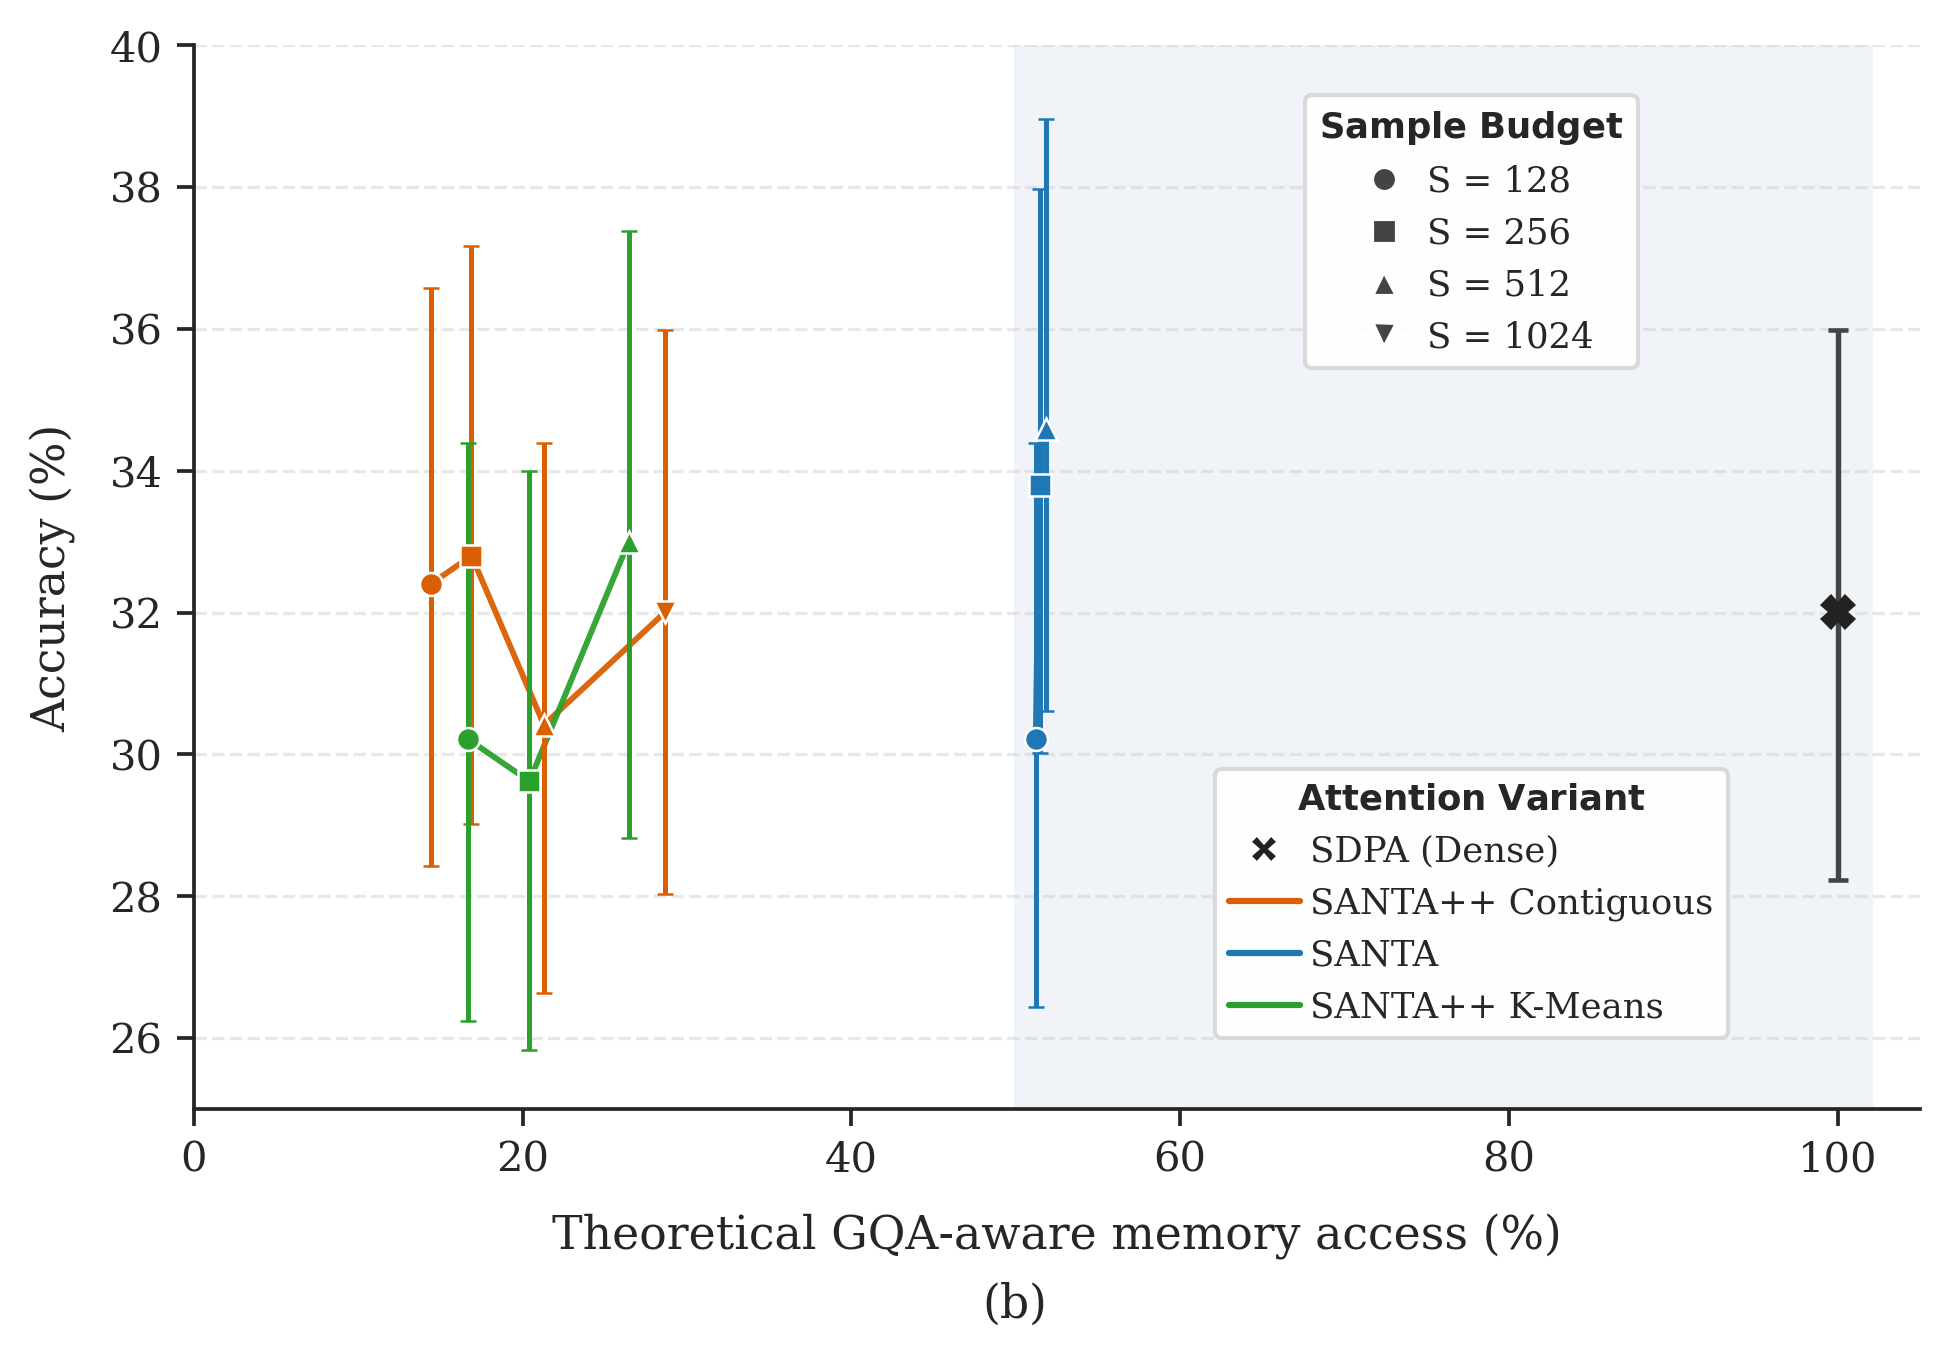

In [10]:
import glob
import json
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# 1. ACCURACY & METRICS EXTRACTION
# ==============================================================================
def extract_strict_mc_choice(pred_text: str) -> str:
    if not pred_text or not isinstance(pred_text, str):
        return ""
    clean = pred_text.strip()
    hedge = r"(?:maybe|perhaps|probably|likely|could\s+be|might\s+be|either)"

    m = list(
        re.finditer(
            r"(?:Final\s+Answer|Final\s+Choice)\*{0,2}\s*[:\-]?\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
            clean,
            re.IGNORECASE,
        )
    )
    if m:
        for match in m:
            post = clean[match.start() : match.end() + 20]
            pre = clean[max(0, match.start() - 25) : match.start()]
            if re.search(r"[A-D]\s*(?:/|or|and|,)\s*[A-D]", post, re.IGNORECASE):
                return ""
            if re.search(hedge, pre, re.IGNORECASE):
                return ""
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    m = list(
        re.finditer(
            r"(?:(?:correct|best)\s+(?:option|choice|answer)\s+is|matches\s+option)\s*[\*\_\[\(]*([A-D])[\*\_\]\)]*",
            clean,
            re.IGNORECASE,
        )
    )
    if m:
        letters = {match.group(1).upper() for match in m}
        return m[-1].group(1).upper() if len(letters) == 1 else ""

    lines = [l.strip() for l in clean.splitlines() if l.strip()]
    if lines:
        match = re.match(r"^[\*\_\[\(]*([A-D])[\*\_\]\)\.]*$", lines[-1])
        if match:
            return match.group(1).upper()
    return ""


def compute_bootstrap_ci(
    correct_array: np.ndarray, n_bootstraps: int = 2000, seed: int = 42
):
    rng = np.random.default_rng(seed)
    n = len(correct_array)
    boot_indices = rng.integers(0, n, size=(n_bootstraps, n))
    boot_accs = correct_array[boot_indices].mean(axis=1) * 100.0
    return np.percentile(boot_accs, 2.5), np.percentile(boot_accs, 97.5)


def evaluate_jsonl(filepath: str, n_bootstraps: int = 2000):
    if not os.path.exists(filepath):
        return None

    correct_list, gqa_access_list = [], []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            item = json.loads(line)
            out = item.get("outputs") or item.get("output") or item.get("answer")
            target = (
                str(out[0] if isinstance(out, list) else out)
                .strip("[]'\" ")
                .upper()
            )

            choice = extract_strict_mc_choice(item.get("pred", ""))
            correct_list.append(
                1 if (choice and target and choice == target) else 0
            )

            metrics = item.get("metrics", {})
            gqa_pct = metrics.get(
                "decode_gqa_total_access_pct",
                metrics.get("decode_gqa_kv_access_pct", None),
            )
            if gqa_pct is not None:
                gqa_access_list.append(float(gqa_pct))

    if not correct_list:
        return None

    correct_arr = np.array(correct_list, dtype=np.float32)
    acc = float(np.mean(correct_arr)) * 100.0
    lower_ci, upper_ci = compute_bootstrap_ci(
        correct_arr, n_bootstraps=n_bootstraps
    )

    return {
        "accuracy": acc,
        "err_low": acc - lower_ci,
        "err_high": upper_ci - acc,
        "gqa_access": float(np.mean(gqa_access_list))
        if gqa_access_list
        else 100.0,
    }


# ==============================================================================
# 2. RUN DISCOVERY & DATA COLLECTION
# ==============================================================================
BASE_DIR = r"C:\Users\theep\OPUS Lab Notebooks\benchmarks\longbench"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "benchmarks/longbench"

variants = ["hierarchical", "santa", "santapp"]
sample_budgets = [128, 256, 512, 1024]
run_data = defaultdict(dict)

for var in variants:
    for s in sample_budgets:
        matches = glob.glob(
            os.path.join(
                BASE_DIR,
                var,
                str(s),
                "predictions",
                var,
                "longbench-short.jsonl",
            )
        )
        if not matches:
            matches = glob.glob(
                os.path.join(
                    BASE_DIR, var, str(s), "predictions", "*", "*.jsonl"
                )
            )
        if matches:
            res = evaluate_jsonl(matches[0])
            if res:
                run_data[var][s] = res

sdpa_matches = glob.glob(
    os.path.join(
        BASE_DIR, "sdpa", "predictions", "sdpa", "longbench-short.jsonl"
    )
)
sdpa_res = evaluate_jsonl(sdpa_matches[0]) if sdpa_matches else None
if sdpa_res:
    sdpa_res["gqa_access"] = 100.0


# ==============================================================================
# 3. RESEARCH-GRADE VISUALIZATION
# ==============================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=300)

color_map = {
    "santa": "#1f77b4",  # Blue
    "santapp": "#2ca02c",  # Green
    "hierarchical": "#d95f02",  # Rust orange
}
label_map = {
    "santa": "SANTA",
    "santapp": "SANTA++ K-Means",
    "hierarchical": "SANTA++ Contiguous",
}
marker_map = {
    128: "o",
    256: "s",
    512: "^",
    1024: "v",
}

# Horizontal dodge offsets to prevent error bar collision
dodge_map = {
    "hierarchical": -0.85,
    "santapp": 0.0,
    "santa": 0.85,
}

# 1. Background highlight for >50% access budget
ax.axvspan(50, 102, color="#f0f4f9", zorder=0)

# 2. Subtle horizontal grid
ax.grid(axis="y", linestyle="--", alpha=0.45, color="#cccccc", zorder=1)

# 3. Plot curves and points
for var in variants:
    budgets = sorted(run_data[var].keys())
    if not budgets:
        continue

    raw_x = [run_data[var][s]["gqa_access"] for s in budgets]
    x_vals = [x + dodge_map[var] for x in raw_x]
    y_vals = [run_data[var][s]["accuracy"] for s in budgets]
    y_err_low = [run_data[var][s]["err_low"] for s in budgets]
    y_err_high = [run_data[var][s]["err_high"] for s in budgets]

    c = color_map[var]

    ax.plot(x_vals, y_vals, color=c, linewidth=1.4, alpha=0.95, zorder=3)

    for s, x, y, el, eh in zip(budgets, x_vals, y_vals, y_err_low, y_err_high):
        ax.errorbar(
            x,
            y,
            yerr=[[el], [eh]],
            fmt=marker_map.get(s, "o"),
            color=c,
            ecolor=c,
            elinewidth=1.2,
            capsize=2.0,
            capthick=1.0,
            markersize=5.5,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=4,
        )

# 4. Plot SDPA baseline
if sdpa_res:
    ax.errorbar(
        sdpa_res["gqa_access"],
        sdpa_res["accuracy"],
        yerr=[[sdpa_res["err_low"]], [sdpa_res["err_high"]]],
        fmt="X",
        color="#222222",
        ecolor="#444444",
        elinewidth=1.3,
        capsize=2.5,
        capthick=1.1,
        markersize=7.0,
        zorder=5,
    )

# Axis bounds & styling
ax.set_xlabel(
    "Theoretical GQA-aware memory access (%)", fontweight="medium", labelpad=8
)
ax.set_ylabel("Accuracy (%)", fontweight="medium", labelpad=8)
ax.set_xlim(0, 105)
ax.set_ylim(25, 40)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)
ax.tick_params(direction="out", length=4, width=0.9)

# ------------------------------------------------------------------------------
# 5. OPEN-SPACE LEGEND PLACEMENT (x in [58%, 92%])
# ------------------------------------------------------------------------------
# Top legend: Sample Budget Markers (centered in open space around x=74%)
marker_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker_map[s],
        color="w",
        markerfacecolor="#444444",
        markersize=6,
        label=f"S = {s}",
    )
    for s in sample_budgets
    if any(s in run_data[v] for v in variants)
]
legend1 = ax.legend(
    handles=marker_handles,
    loc="upper center",
    bbox_to_anchor=(0.74, 0.97),  # Places box cleanly between x=55% and 93%
    frameon=True,
    facecolor="white",
    edgecolor="#d8d8d8",
    framealpha=0.95,
    fontsize=8.5,
    title=r"$\bf{Sample\ Budget}$",
    title_fontsize=8.5,
    handletextpad=0.2,
)
ax.add_artist(legend1)

# Bottom legend: Attention Variants & SDPA (positioned below legend 1)
method_handles = []
if sdpa_res:
    method_handles.append(
        plt.Line2D(
            [0],
            [0],
            marker="X",
            color="w",
            markerfacecolor="#222222",
            markersize=7,
            label="SDPA (Dense)",
        )
    )
for var in variants:
    if run_data[var]:
        method_handles.append(
            plt.Line2D(
                [0], [0], color=color_map[var], lw=1.5, label=label_map[var]
            )
        )

ax.legend(
    handles=method_handles,
    loc="lower center",
    bbox_to_anchor=(0.74, 0.05),  # Sits below the data line in the open 55-93% zone
    frameon=True,
    facecolor="white",
    edgecolor="#d8d8d8",
    framealpha=0.95,
    fontsize=8.5,
    title=r"$\bf{Attention\ Variant}$",
    title_fontsize=8.5,
    handletextpad=0.3,
)

fig.text(0.52, -0.01, "(b)", ha="center", fontsize=11, fontweight="medium")

plt.tight_layout()
plt.savefig(
    "accuracy_vs_gqa_memory_access_clear.png", dpi=300, bbox_inches="tight"
)
plt.savefig(
    "accuracy_vs_gqa_memory_access_clear.pdf", bbox_inches="tight"
)  # Vector format for papers
print("Saved cleanly formatted plot with zero data occlusion.")
plt.show()